In [1]:
import os

import numpy as np
from werkzeug.serving import can_fork

from transform_dataset import *
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Index(['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT', 'HUXZ',
       'DUCT', 'SMAH', 'NPCK', 'MSDP', 'EORC', 'CUBO', 'HRET', 'ANSO', 'DIHO',
       'RTTH', 'SPLZ', 'NWIG', 'MMBT', 'MDGI', 'AGVF', 'RRES', 'CTGI', 'ALUT',
       'ACAC', 'SRTX', 'GARI', 'RCRI', 'ACIX', 'CCNS', 'MTNS', 'IHOZ', 'NAYO',
       'FWWG', 'EELT', 'HRND', 'AETS', 'ULXY', 'BLBT', 'BENI', 'ITPA', 'HTRK',
       'NGTE', 'ILVX', 'FCSG', 'FARS', 'MHRM', 'EAFC'],
      dtype='str')


Load in Data

In [2]:
prices = load_dataset('prices.csv')
prices

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,91.50,63.01,84.84,54.59,51.45,23.80,24.05,69.32,47.71,13.22,...,28.72,29.97,25.35,9.76,36.21,44.23,21.73,34.04,12.51,26.41
746,90.80,63.97,83.99,54.10,50.22,23.70,23.75,68.31,47.34,13.10,...,28.71,29.70,25.48,9.90,35.65,44.01,21.61,33.63,12.42,26.03
747,90.95,64.16,84.85,54.77,48.63,23.47,23.30,69.35,46.89,13.12,...,28.31,29.32,25.28,9.86,35.97,44.33,20.53,33.79,12.49,26.39
748,93.20,63.80,88.05,57.77,48.63,23.87,23.94,69.94,46.72,13.59,...,28.59,30.06,25.59,10.48,36.06,44.92,20.22,34.31,12.82,27.10


In [3]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ALGO    750 non-null    float64
 1   AENO    750 non-null    float64
 2   LSST    750 non-null    float64
 3   SRNA    750 non-null    float64
 4   ELLT    750 non-null    float64
 5   AMRP    750 non-null    float64
 6   OTCS    750 non-null    float64
 7   HETT    750 non-null    float64
 8   HUXZ    750 non-null    float64
 9   DUCT    750 non-null    float64
 10  SMAH    750 non-null    float64
 11  NPCK    750 non-null    float64
 12  MSDP    750 non-null    float64
 13  EORC    750 non-null    float64
 14  CUBO    750 non-null    float64
 15  HRET    750 non-null    float64
 16  ANSO    750 non-null    float64
 17  DIHO    750 non-null    float64
 18  RTTH    750 non-null    float64
 19  SPLZ    750 non-null    float64
 20  NWIG    750 non-null    float64
 21  MMBT    750 non-null    float64
 22  MDGI    750 n

In [4]:
print(prices.describe())

             ALGO        AENO        LSST        SRNA        ELLT        AMRP  \
count  750.000000  750.000000  750.000000  750.000000  750.000000  750.000000   
mean    95.701053   85.254067   87.264907   96.653187   82.379293   17.984480   
std      9.312183   23.854649   11.990580   31.905788   19.900461    3.419987   
min     77.200000   52.500000   61.730000   48.810000   42.520000   11.550000   
25%     87.592500   63.940000   78.975000   62.907500   67.455000   15.465000   
50%     97.520000   74.960000   84.460000   98.300000   80.235000   16.755000   
75%    103.675000  107.967500   93.887500  121.060000   98.565000   20.740000   
max    115.420000  133.520000  122.860000  166.260000  123.030000   26.230000   

             OTCS        HETT        HUXZ        DUCT  ...        BLBT  \
count  750.000000  750.000000  750.000000  750.000000  ...  750.000000   
mean    24.777413   63.587427   63.454253   15.972907  ...   38.828587   
std      6.806483    7.422066   14.672159    4.1

Per Instrument Summary Stats:

In [5]:
for instruments in prices.columns:
    mean = prices[instruments].mean()
    std = prices[instruments].std()
    var = std**2
    median = prices[instruments].median()
    skew = prices[instruments].skew()
    kurtosis = prices[instruments].kurtosis()
    print(f"Instrument Name: {instruments}\n"
          f"Mean: {mean}\n"
          f"Std: {std}\n"
          f"Median : {median}\n"
          f"Std / Mean: {std/mean}\n"
          f"Variance: {var}\n"
          f"Skew: {skew}\n"
          f"Kurtosis: {kurtosis}\n")

Instrument Name: ALGO
Mean: 95.70105333333335
Std: 9.312183491121651
Median : 97.52000000000001
Std / Mean: 0.09730492159461063
Variance: 86.71676137231862
Skew: -0.06131601475110267
Kurtosis: -1.1472330178226255

Instrument Name: AENO
Mean: 85.25406666666666
Std: 23.854649184435853
Median : 74.96000000000001
Std / Mean: 0.2798065842149761
Variance: 569.0442877125062
Skew: 0.4307943801150324
Kurtosis: -1.3415685696495443

Instrument Name: LSST
Mean: 87.26490666666668
Std: 11.990579621415261
Median : 84.46
Std / Mean: 0.13740437112041748
Variance: 143.77399965749893
Skew: 1.0095467574488919
Kurtosis: 0.9016018022588823

Instrument Name: SRNA
Mean: 96.65318666666667
Std: 31.905788478420792
Median : 98.3
Std / Mean: 0.3301059135117406
Variance: 1017.979338429729
Skew: 0.19197467750474687
Kurtosis: -1.0980869476333823

Instrument Name: ELLT
Mean: 82.37929333333334
Std: 19.900461304052918
Median : 80.23500000000001
Std / Mean: 0.24157115822211775
Variance: 396.02836011410756
Skew: 0.0317983

Price Distribution Plots

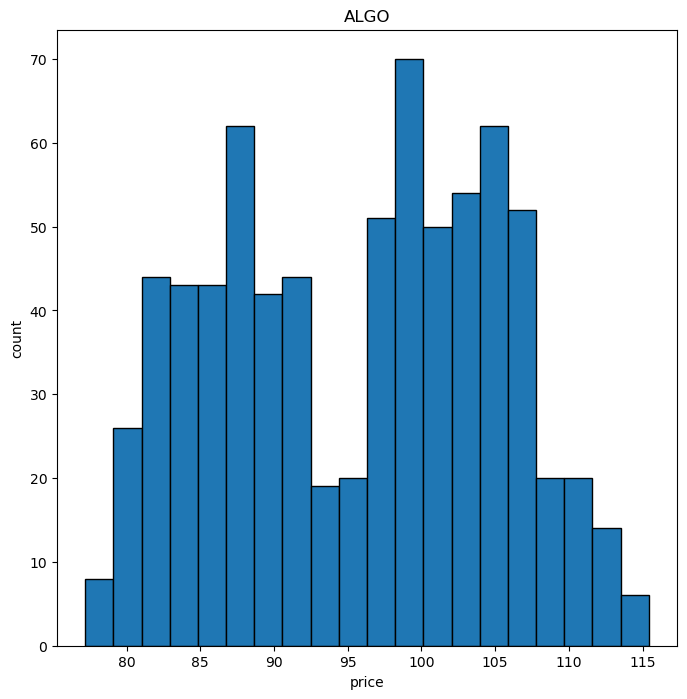

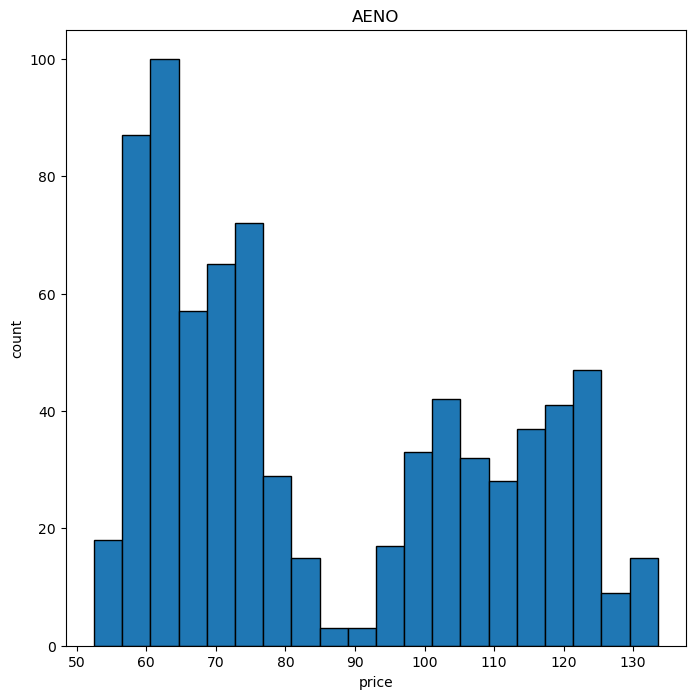

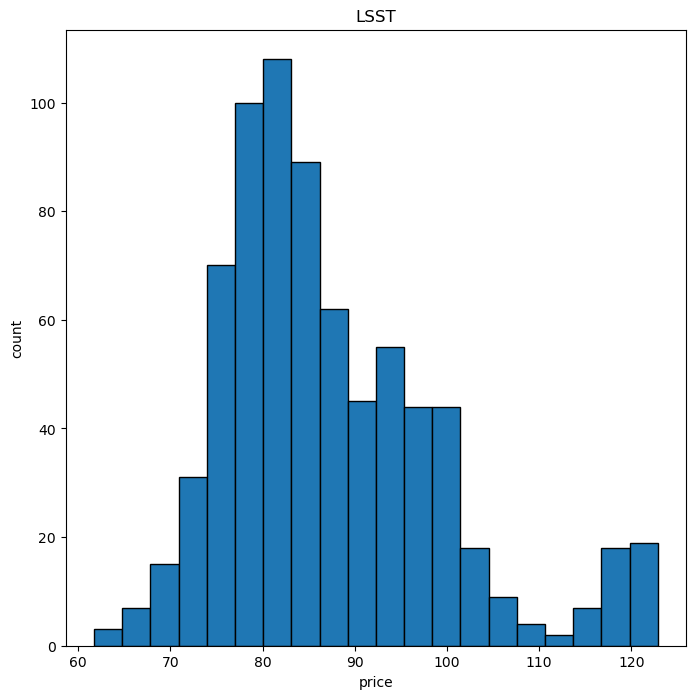

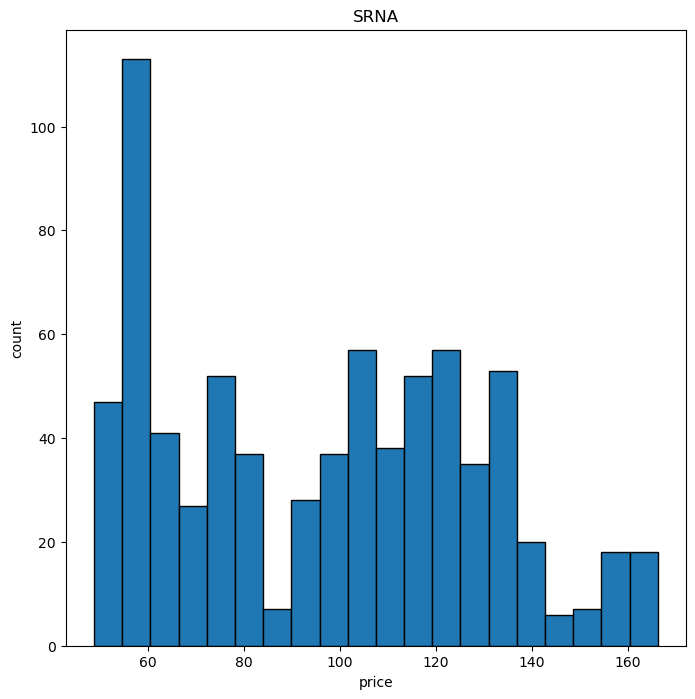

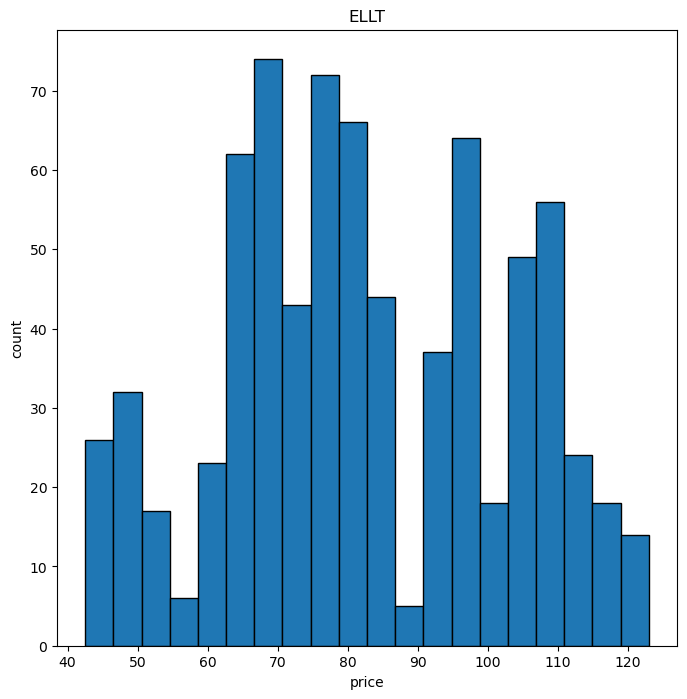

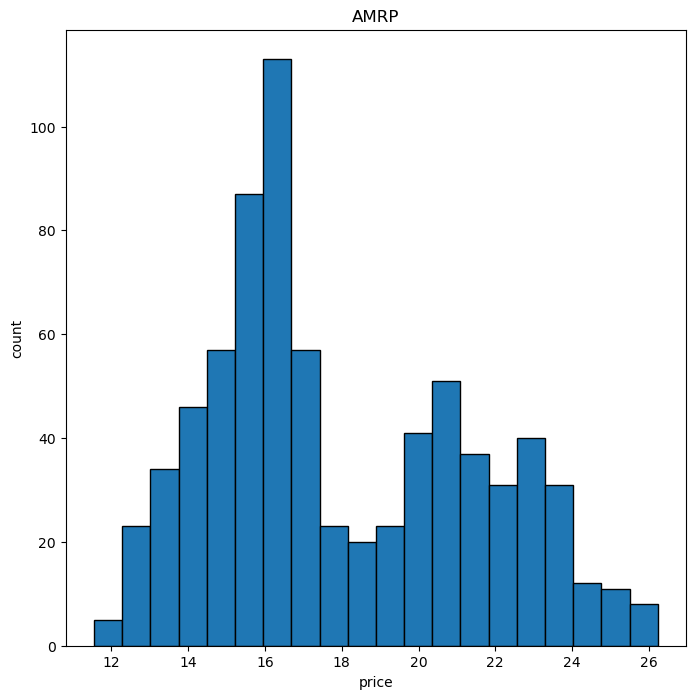

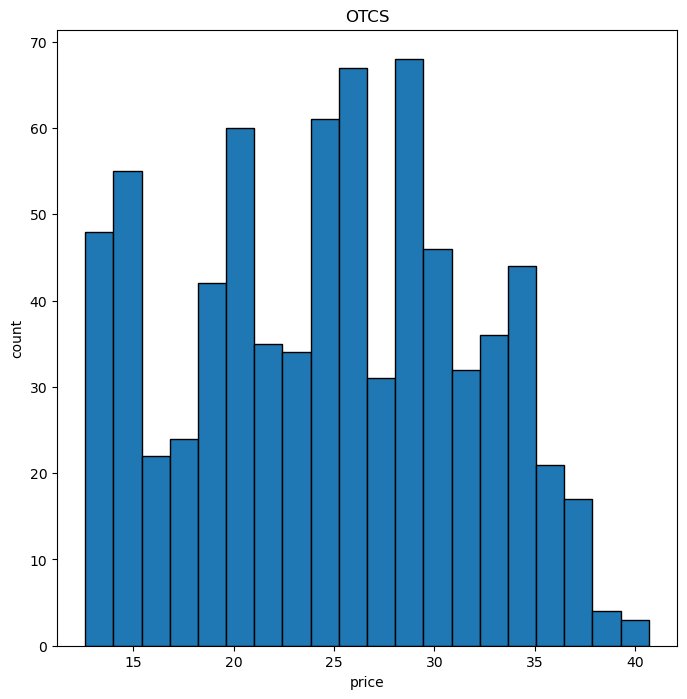

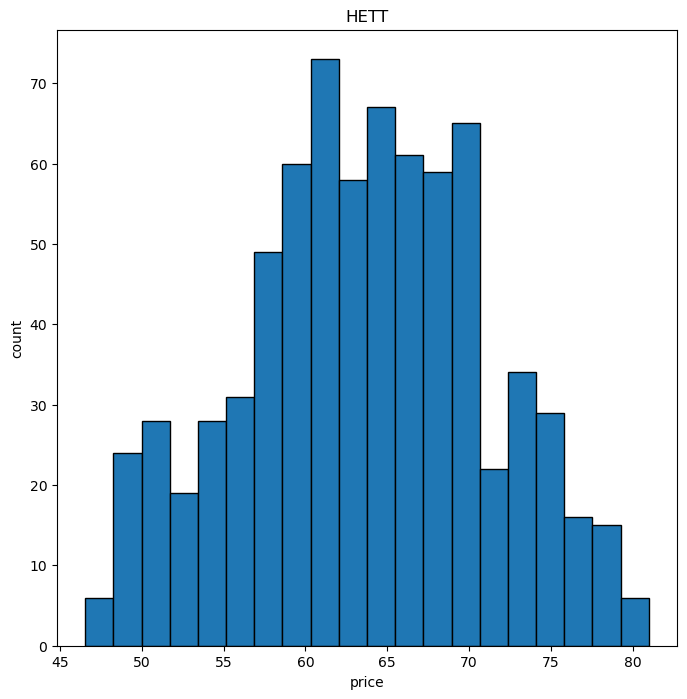

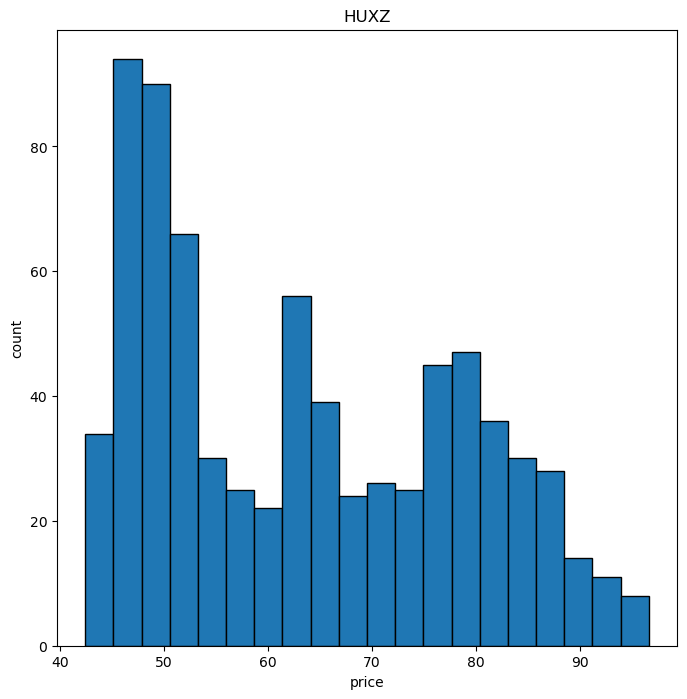

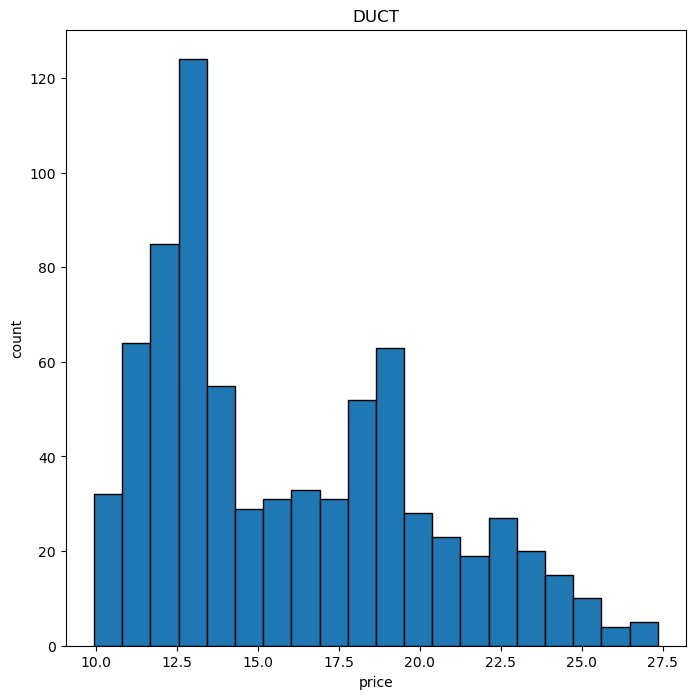

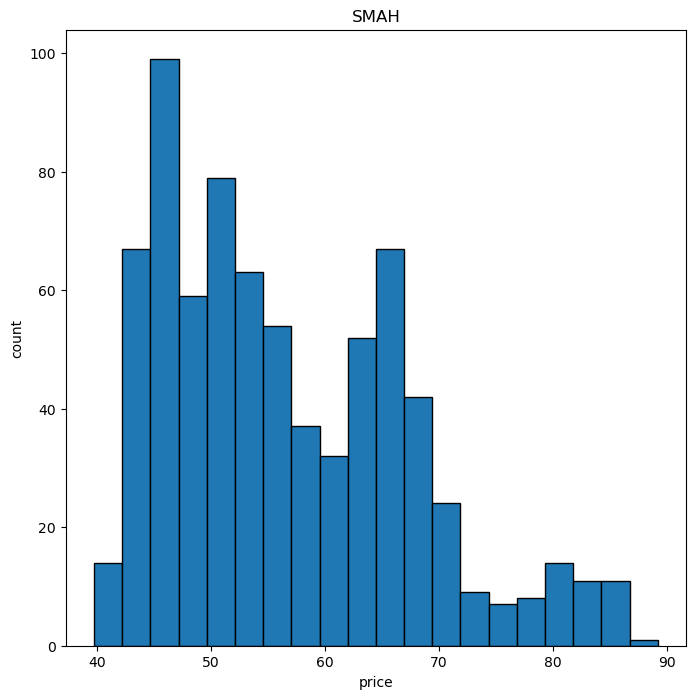

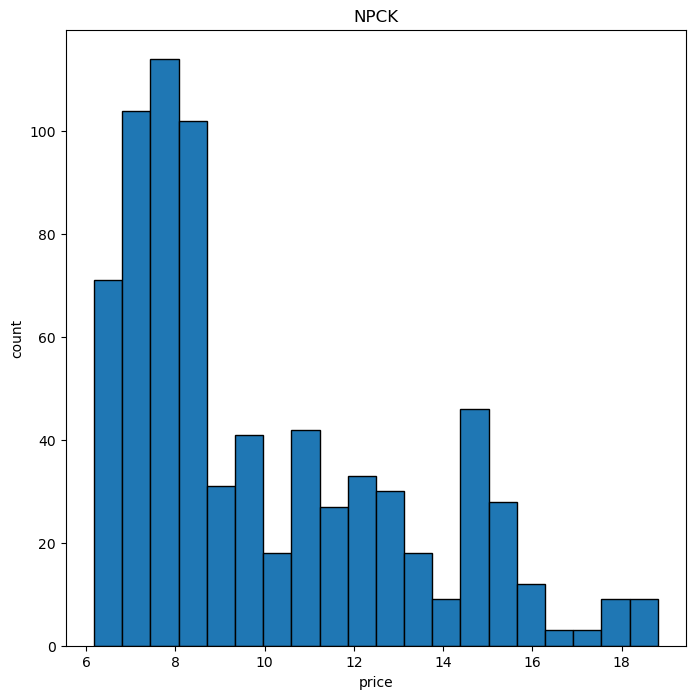

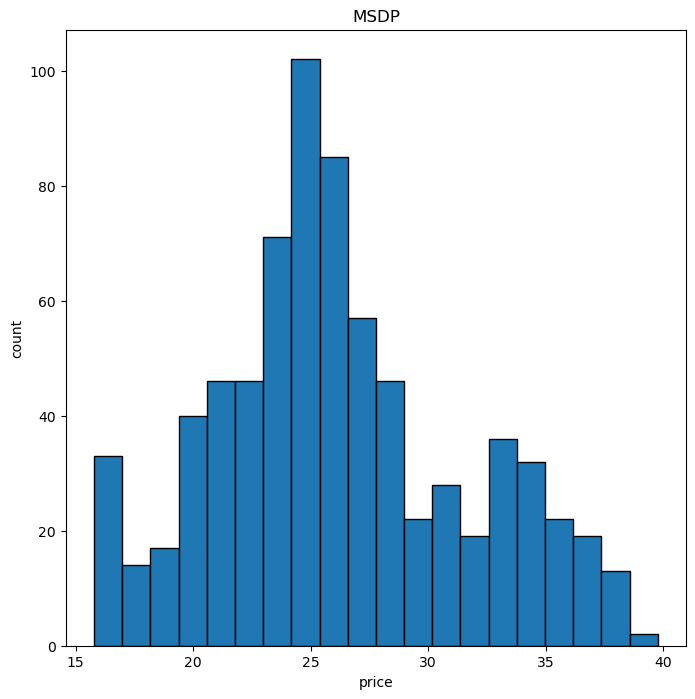

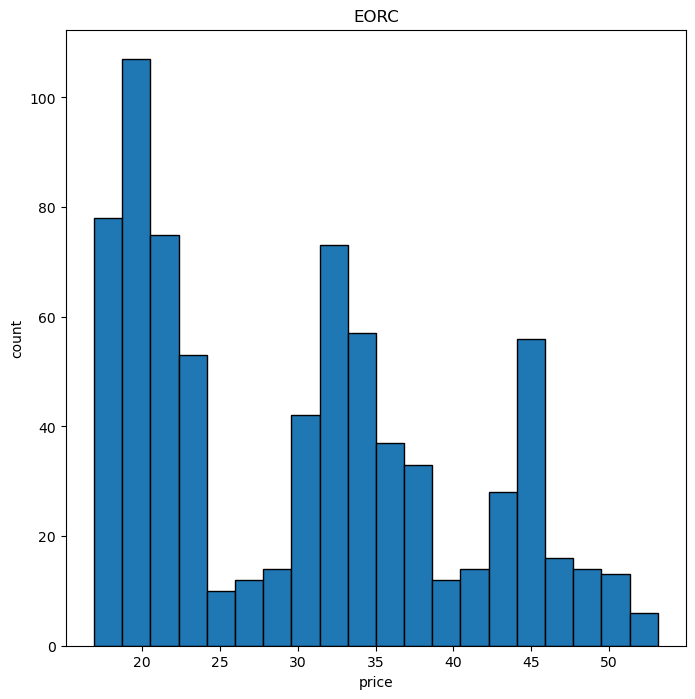

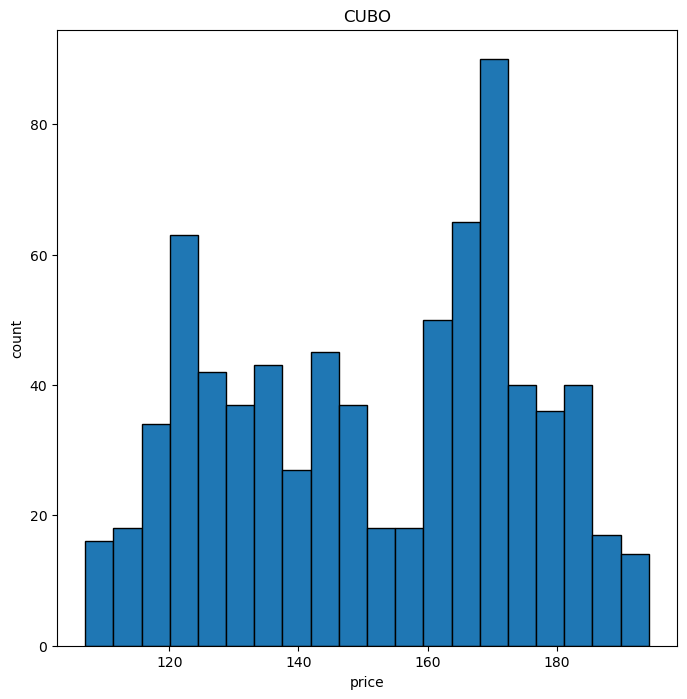

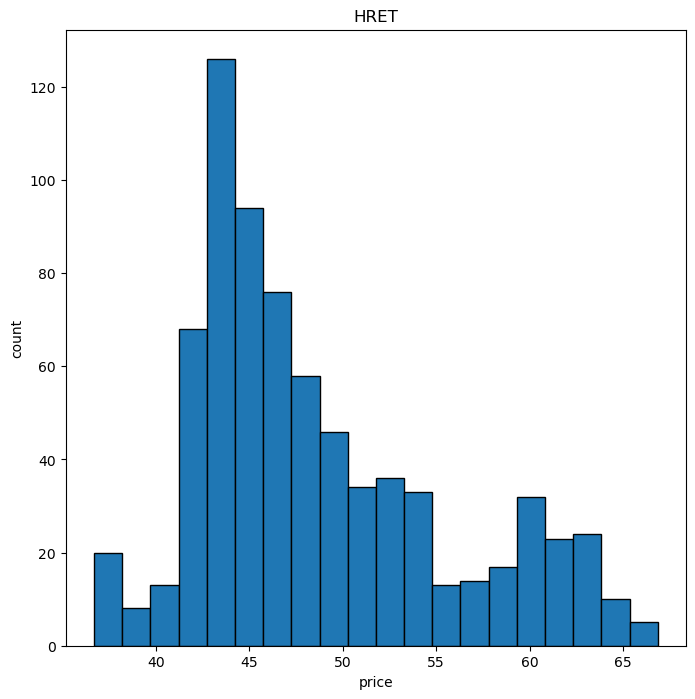

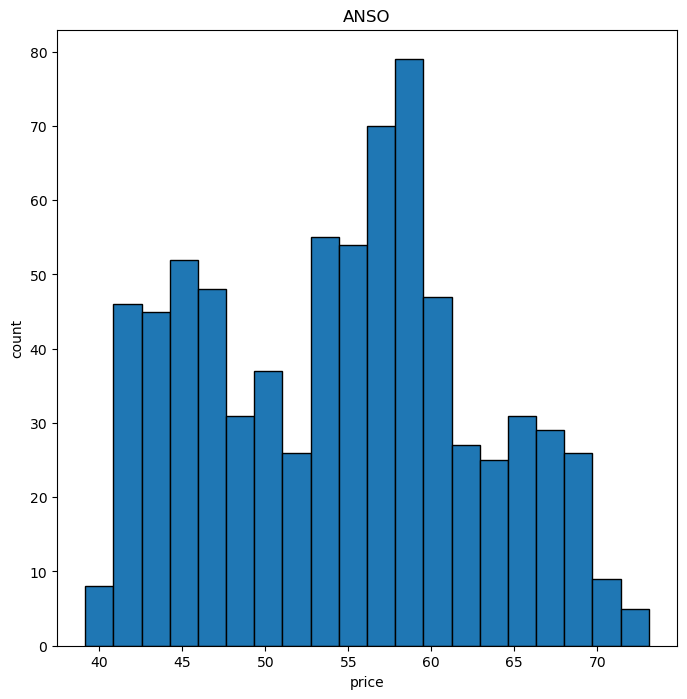

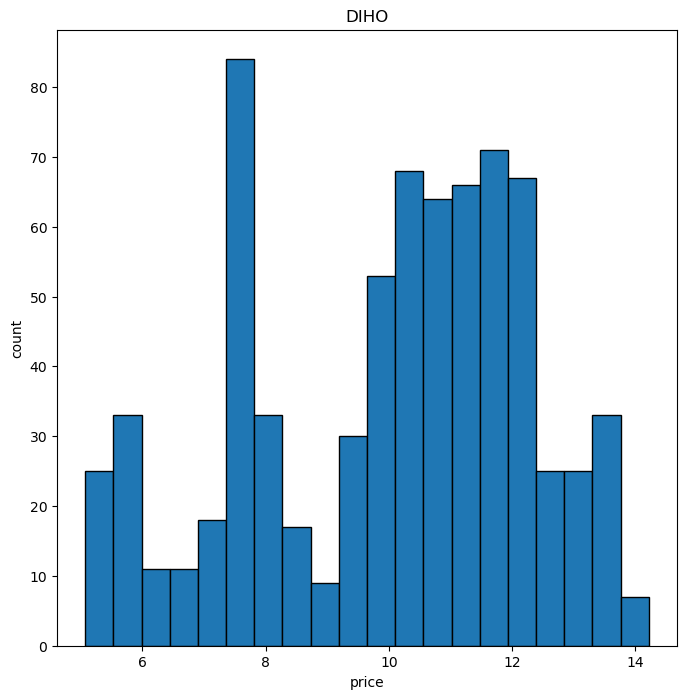

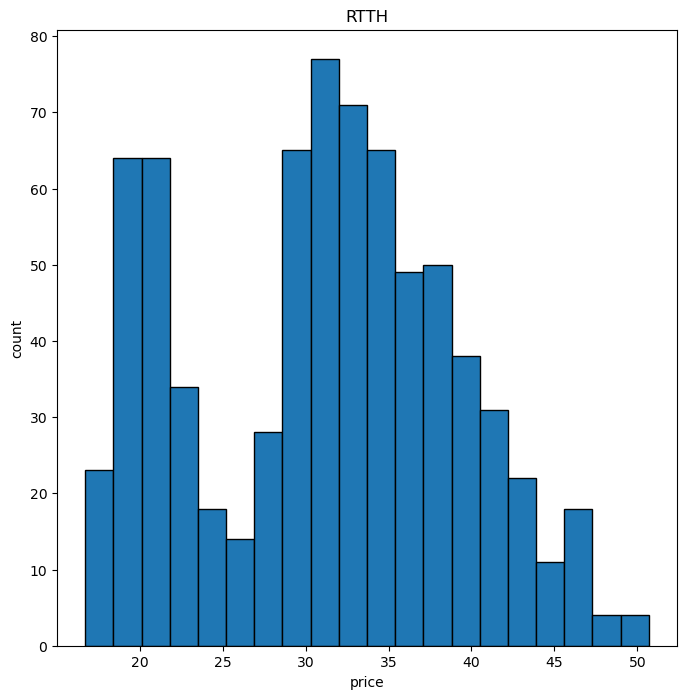

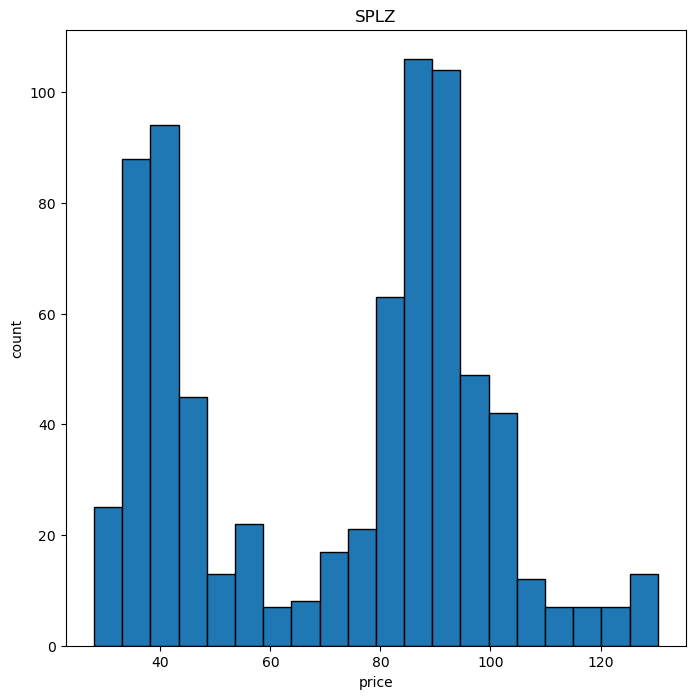

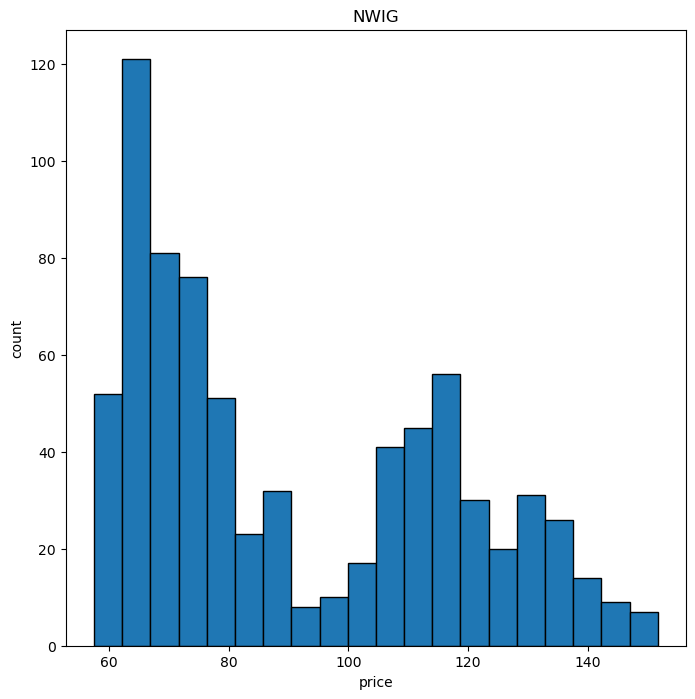

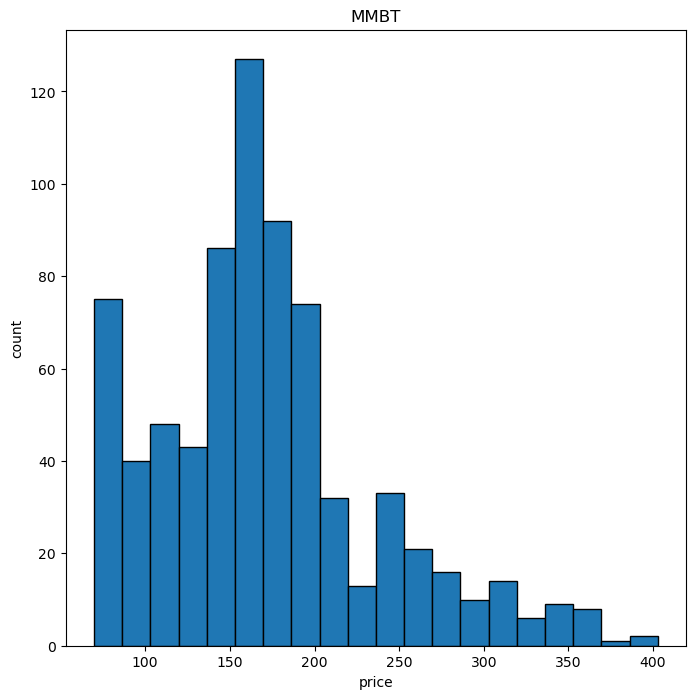

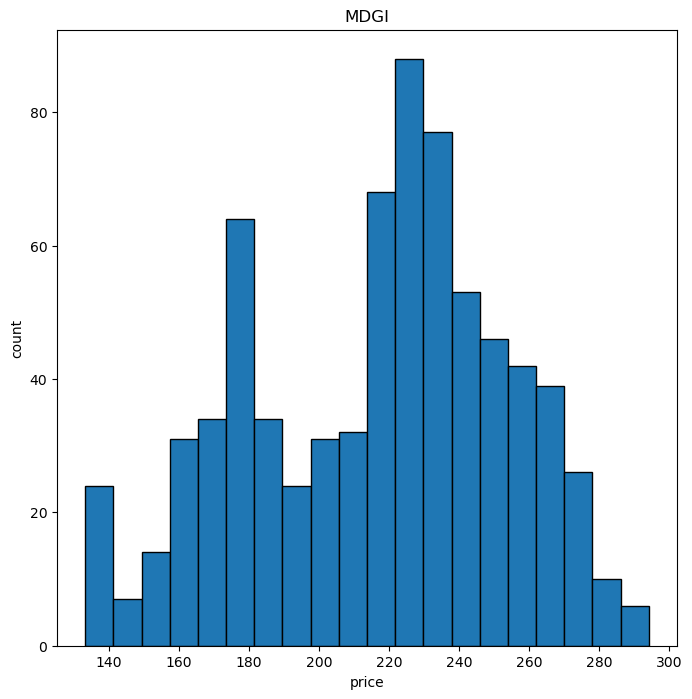

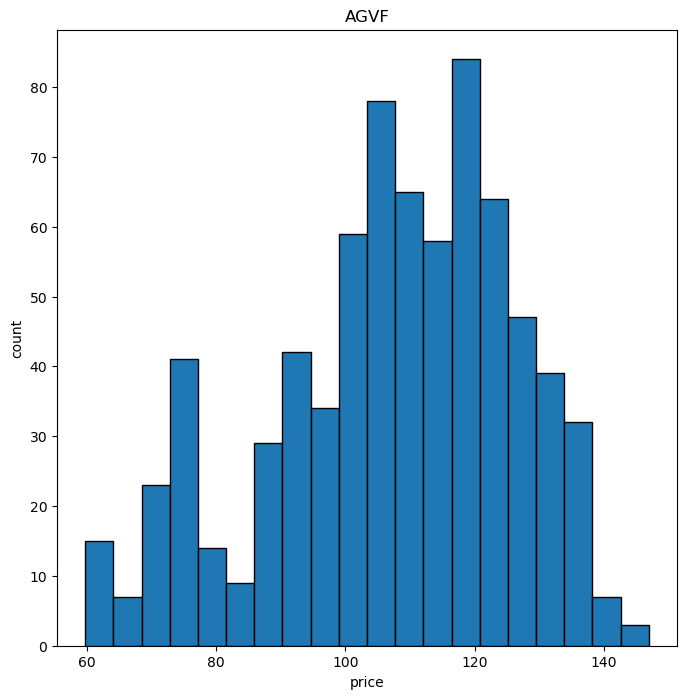

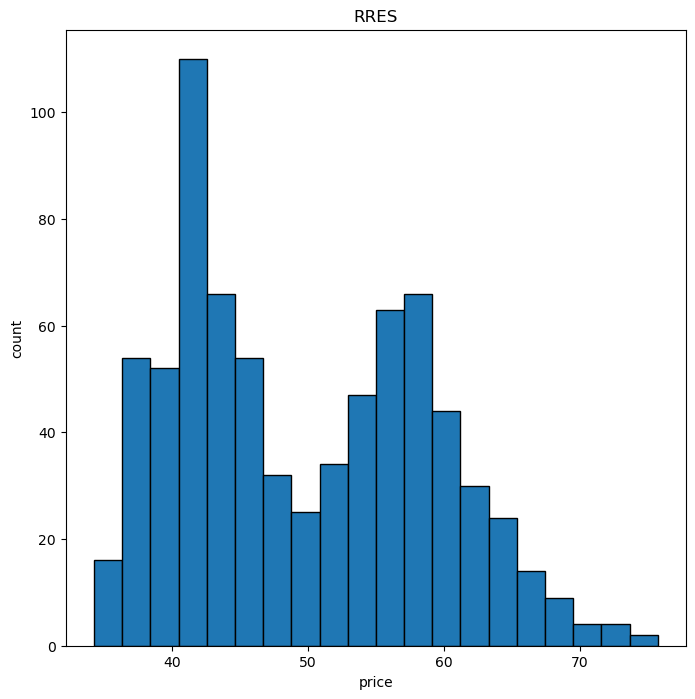

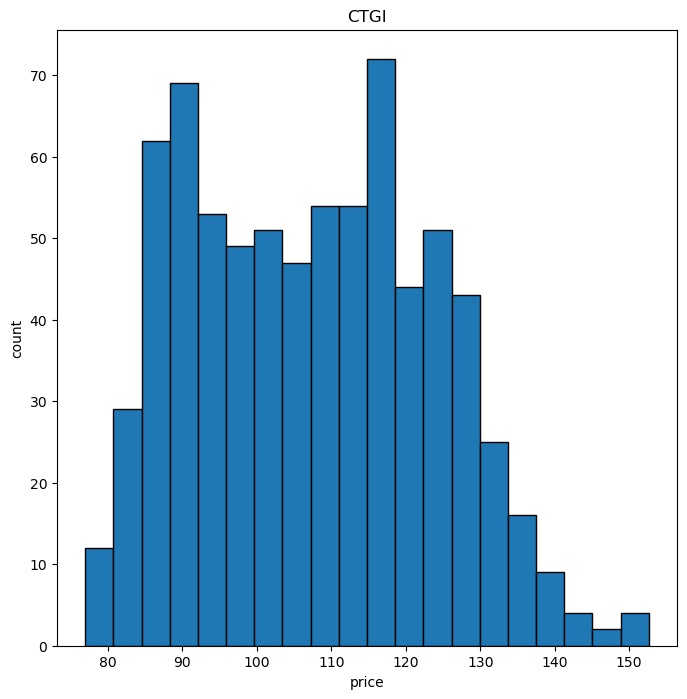

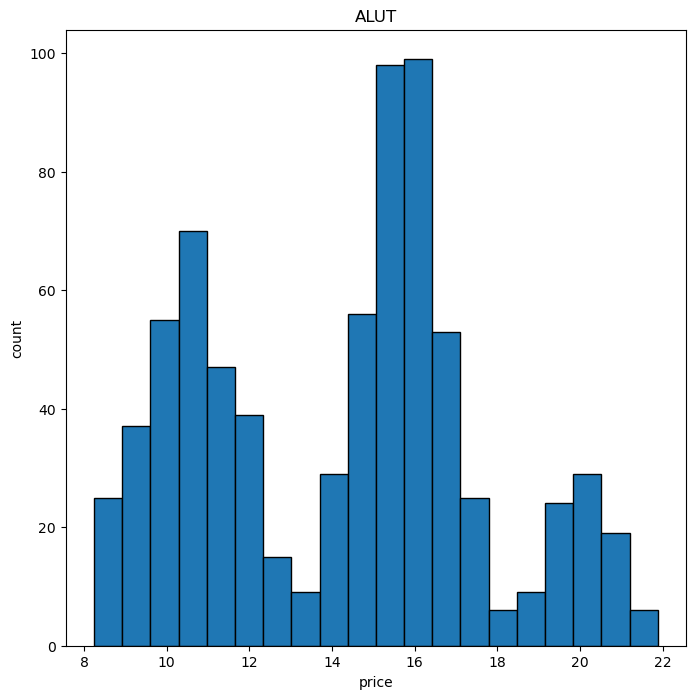

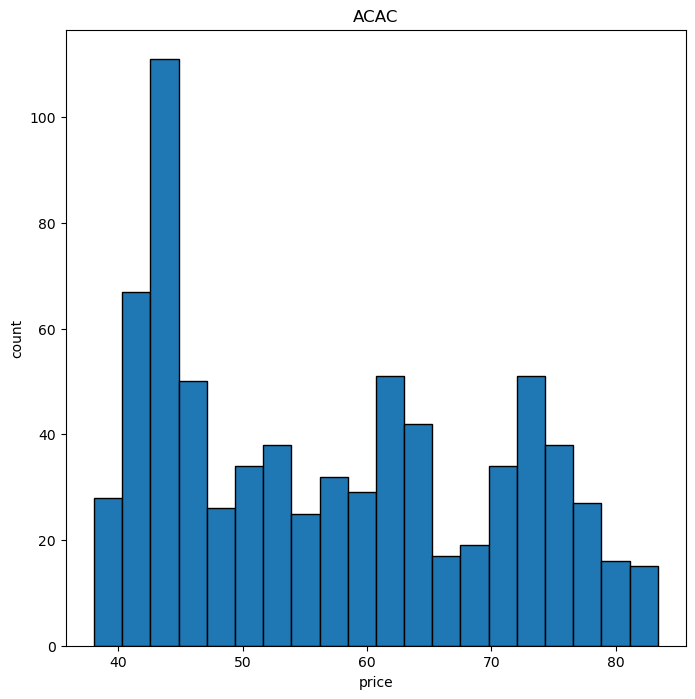

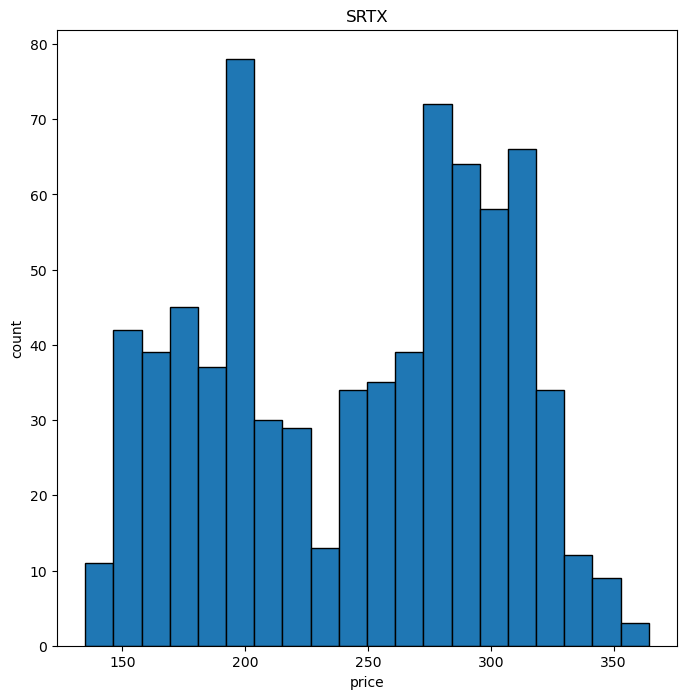

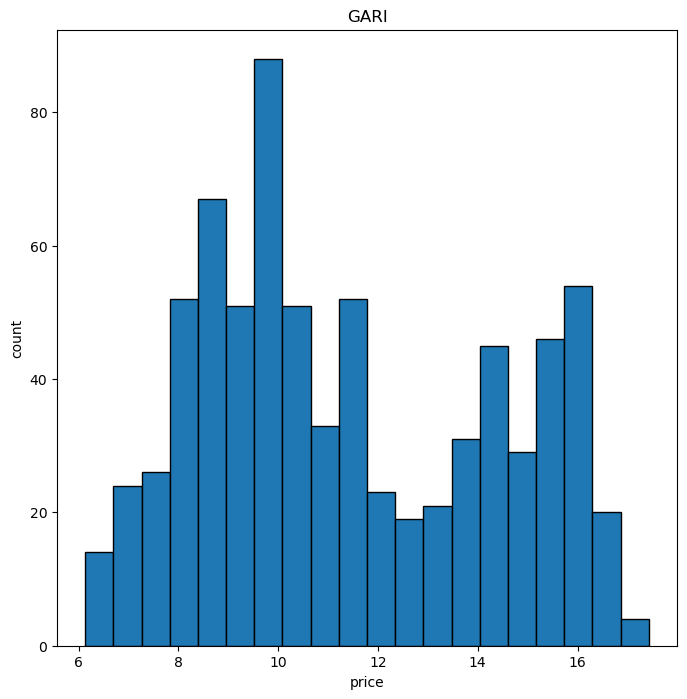

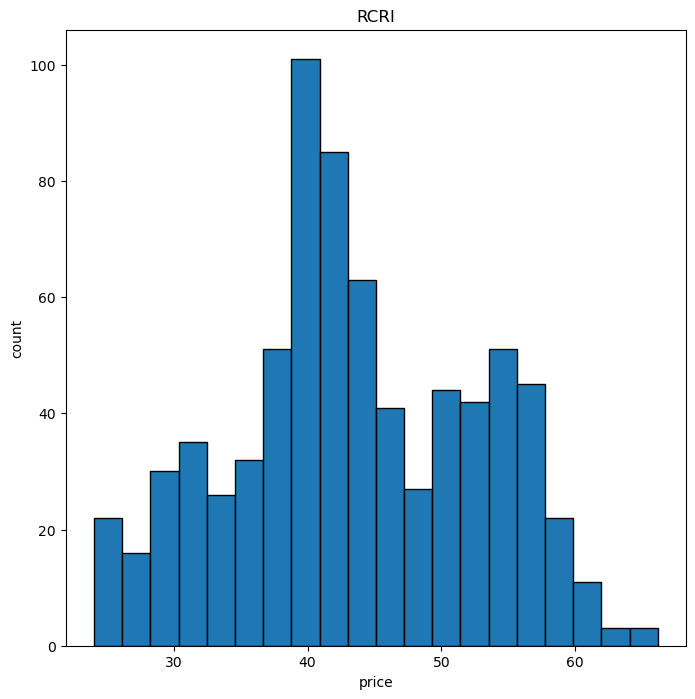

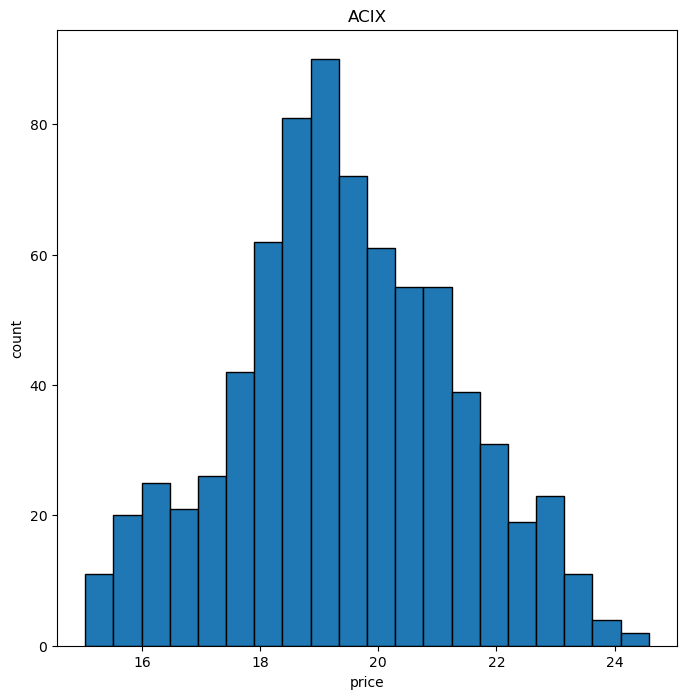

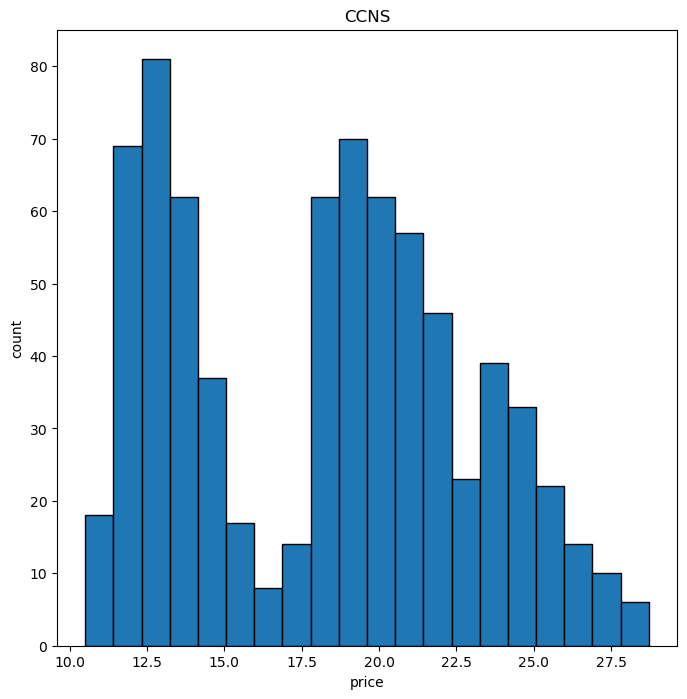

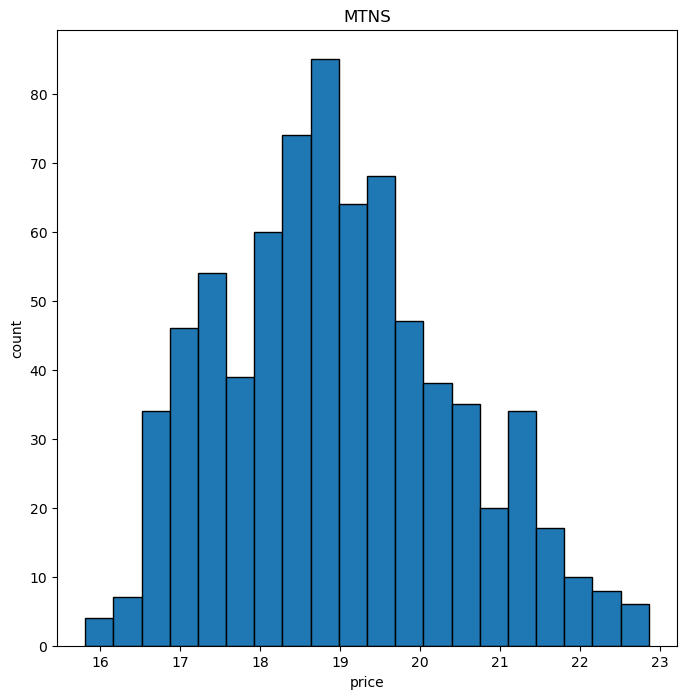

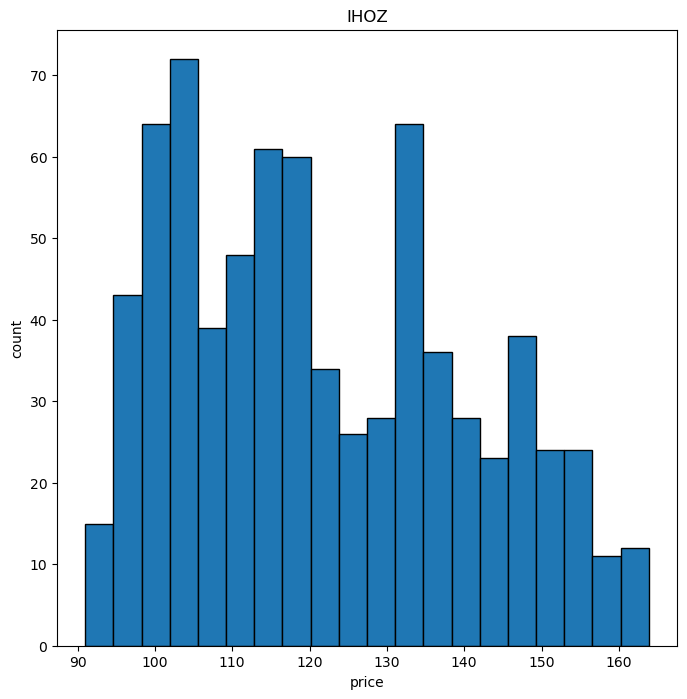

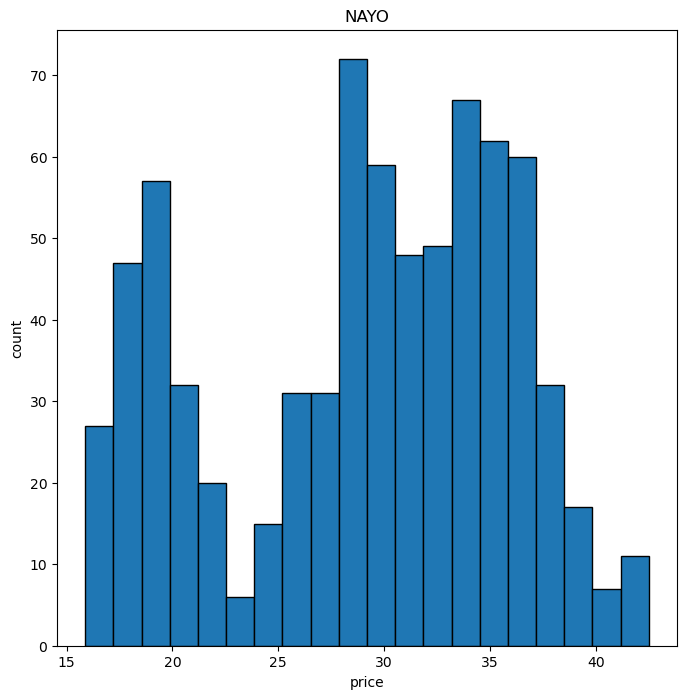

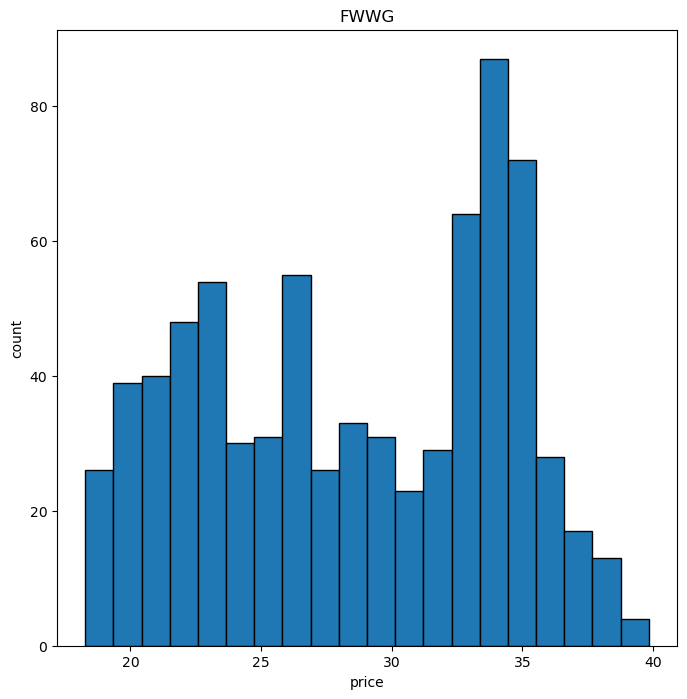

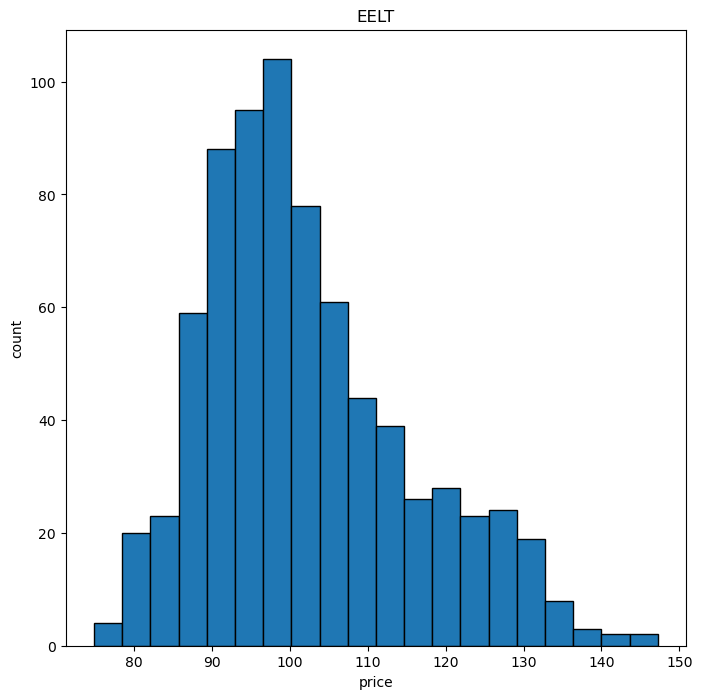

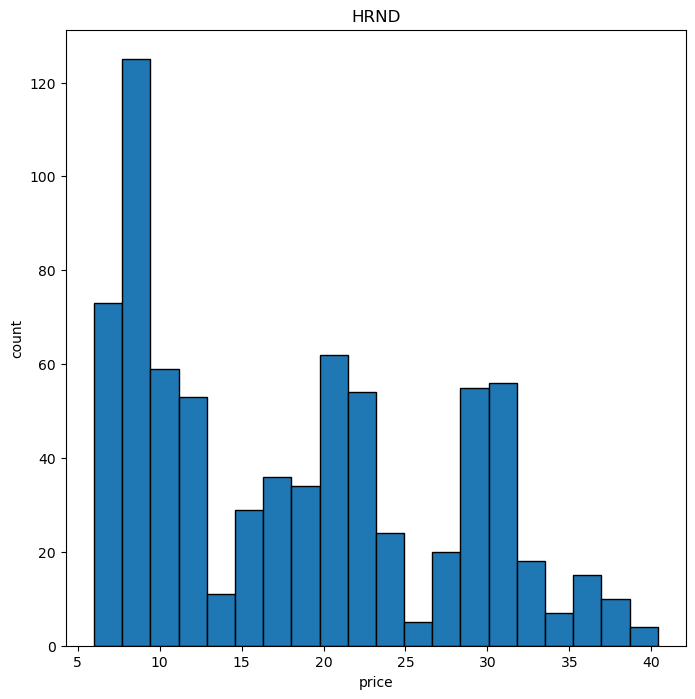

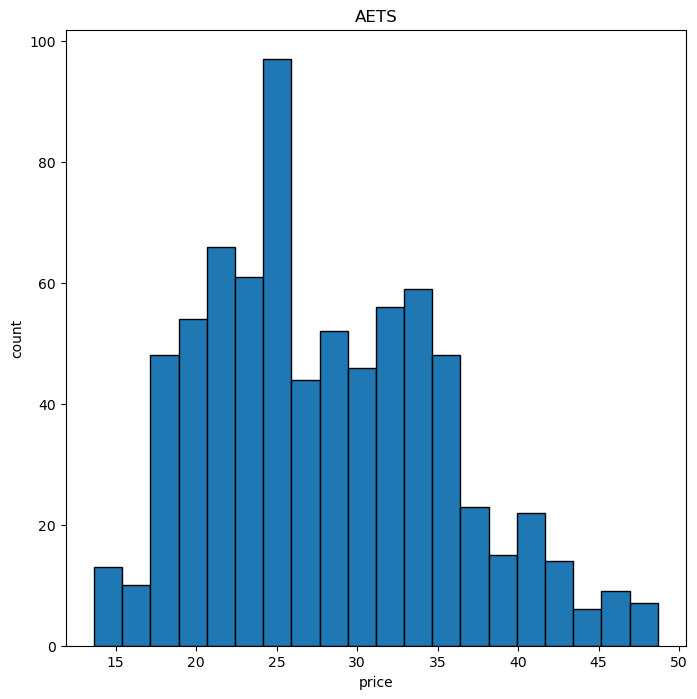

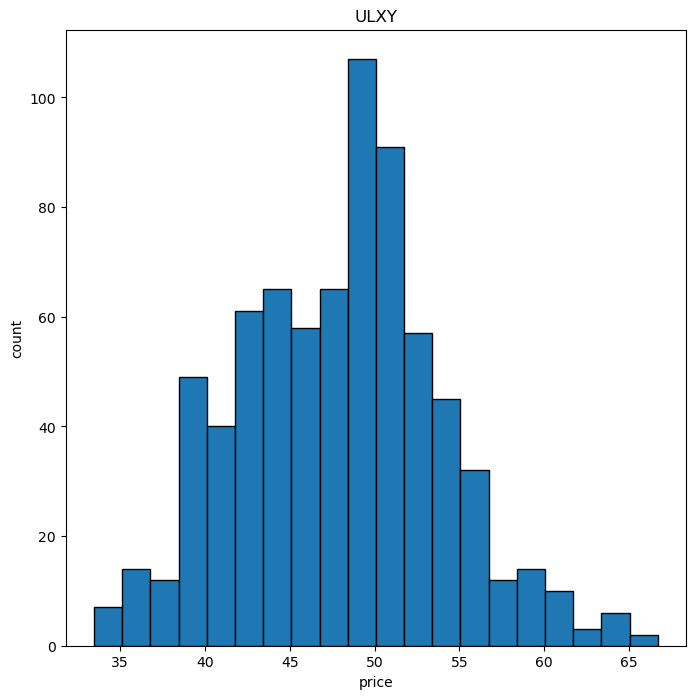

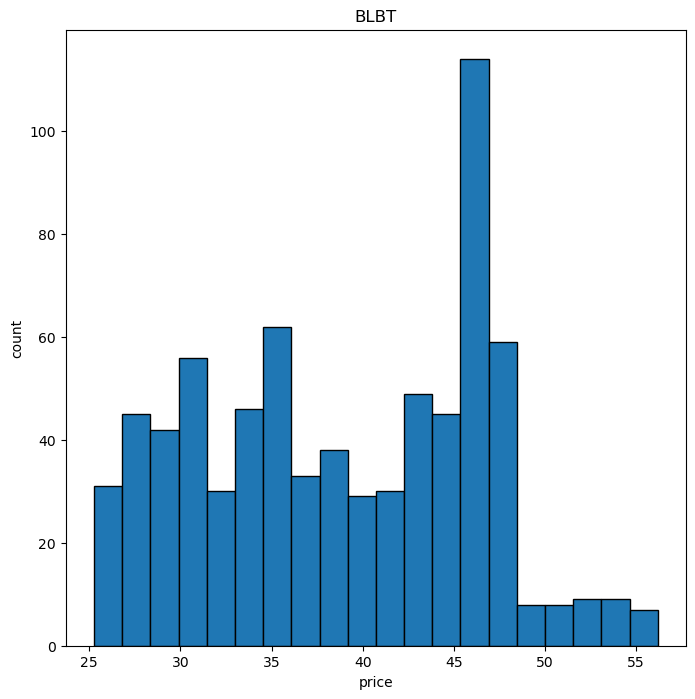

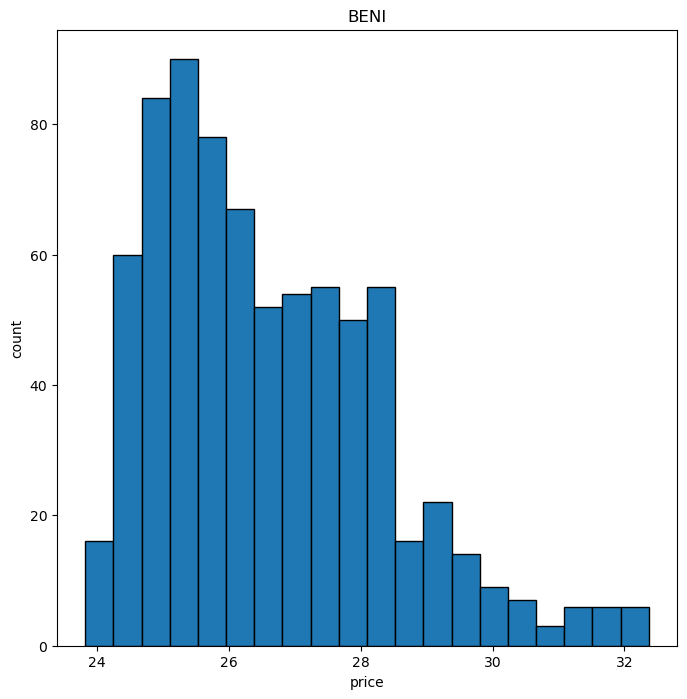

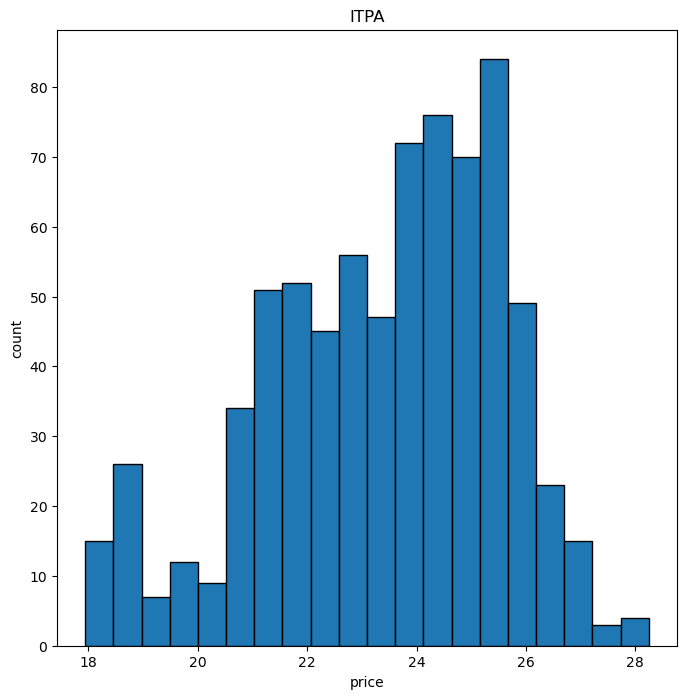

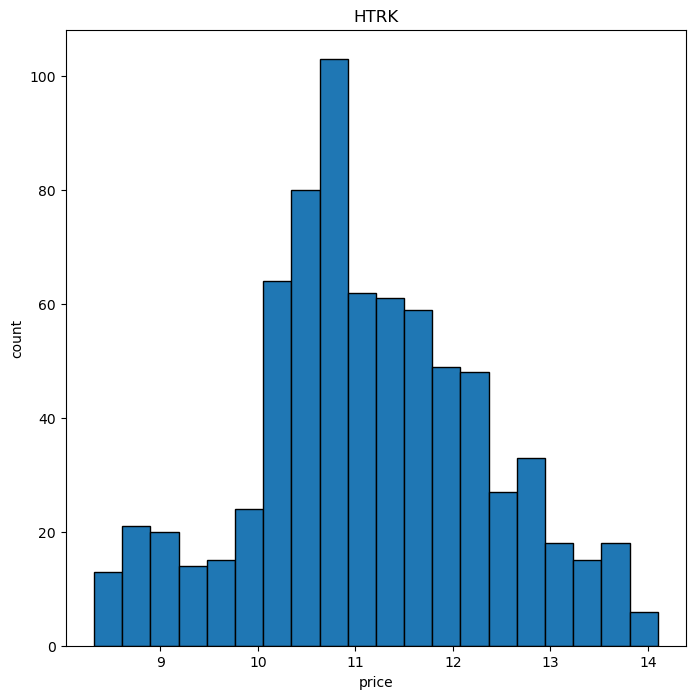

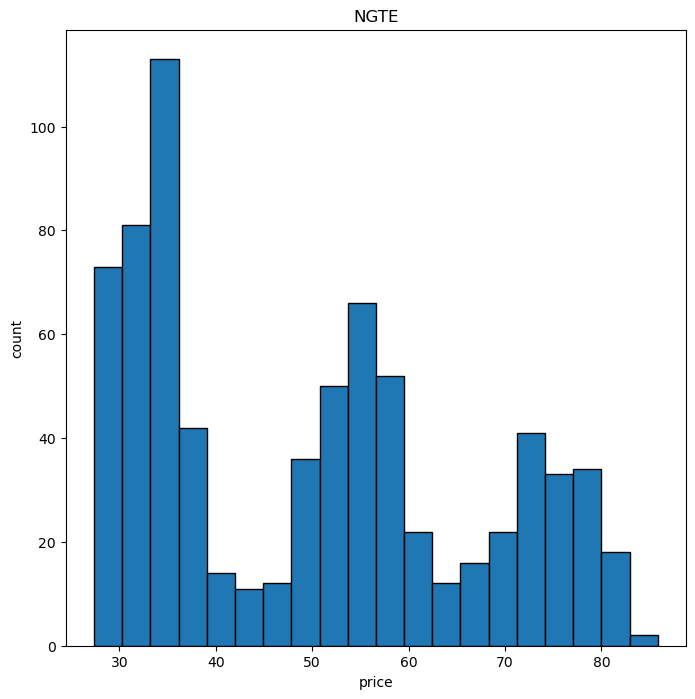

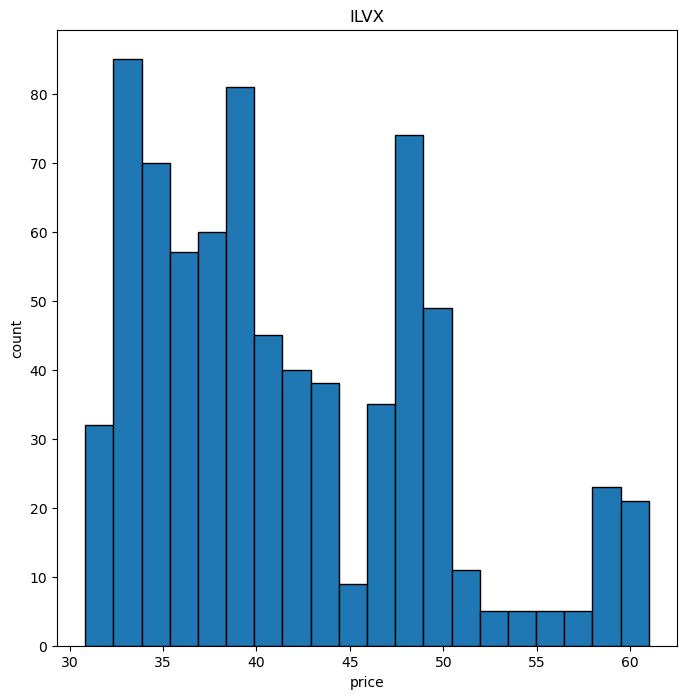

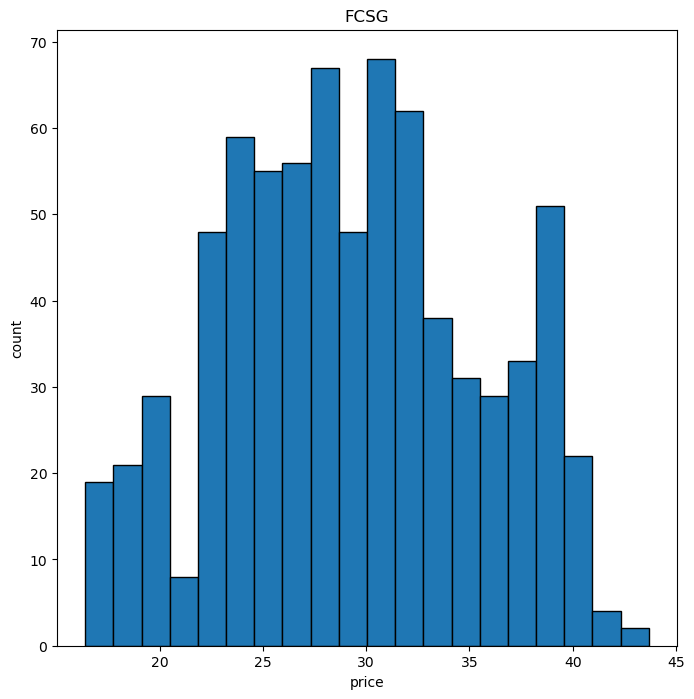

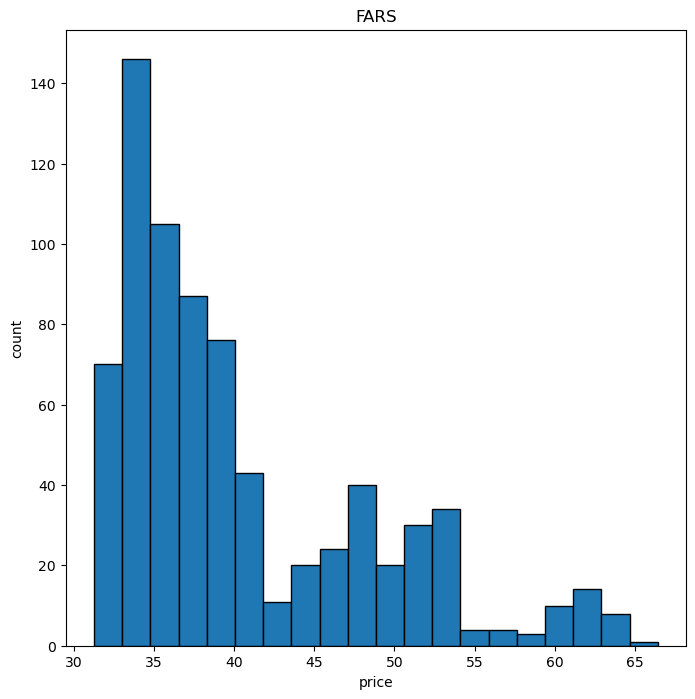

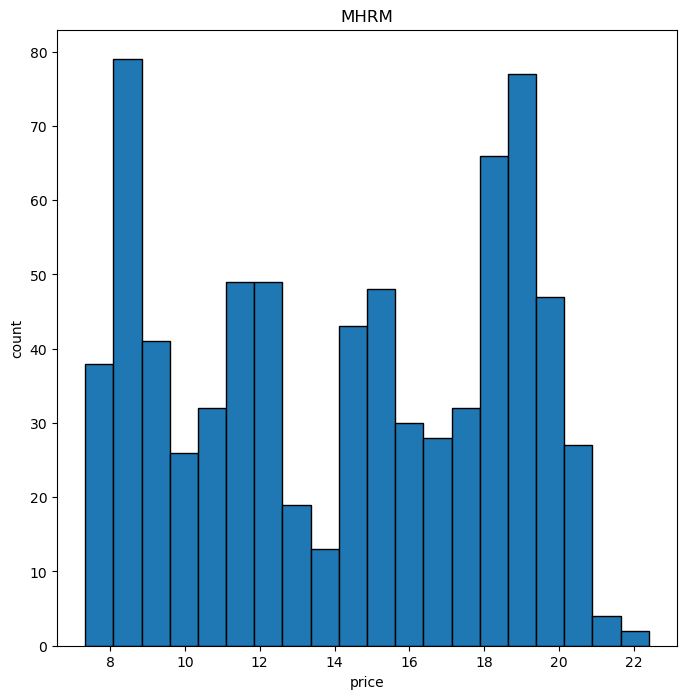

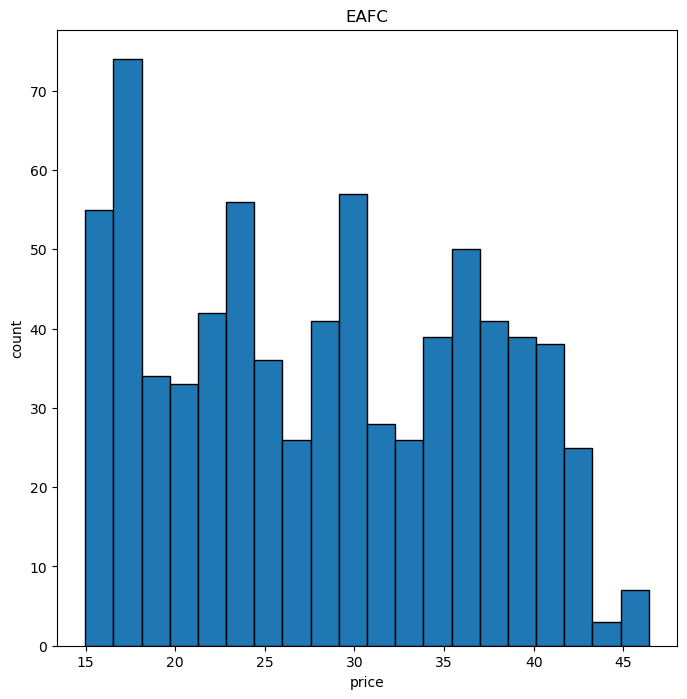

In [6]:
for instruments in prices.columns:
    plt.figure(figsize=(8,8))
    plt.hist(prices[instruments], edgecolor='black', bins=20)
    plt.title(instruments)
    plt.xlabel('price')
    plt.ylabel('count')
    plt.show()

SPLZ seems to be normally distributed mainly, BENI is bimodal and looking at its price data, seems to have a regime shift.  Seems that multiple peaks are indicative of regime shifts, so going to have to find a way to combat that regime shift somehow, and detect its onset.  Perhaps the key to regime shift detection is in other instruments

Prices Vs Time

On The Plotly Express Plots file, will create an HTML for easier observation

ADF Test, checks for stationarity, results are on ADF_ACF_tests script, notebook had an issue:
For ADF Test: the following stocks were interesting and had notable results:
For constant regression component used:
MTNS, NAYO, EELT, ULXY, BENI.
For constant and trend regression component used (stationary around a trending mean):
NAYO, MTNS, GARI, RTTH

NAYO seems to be mean reverting around some moving/trending target while MTNS is mean reverting around some constant mean.  

<Axes: >

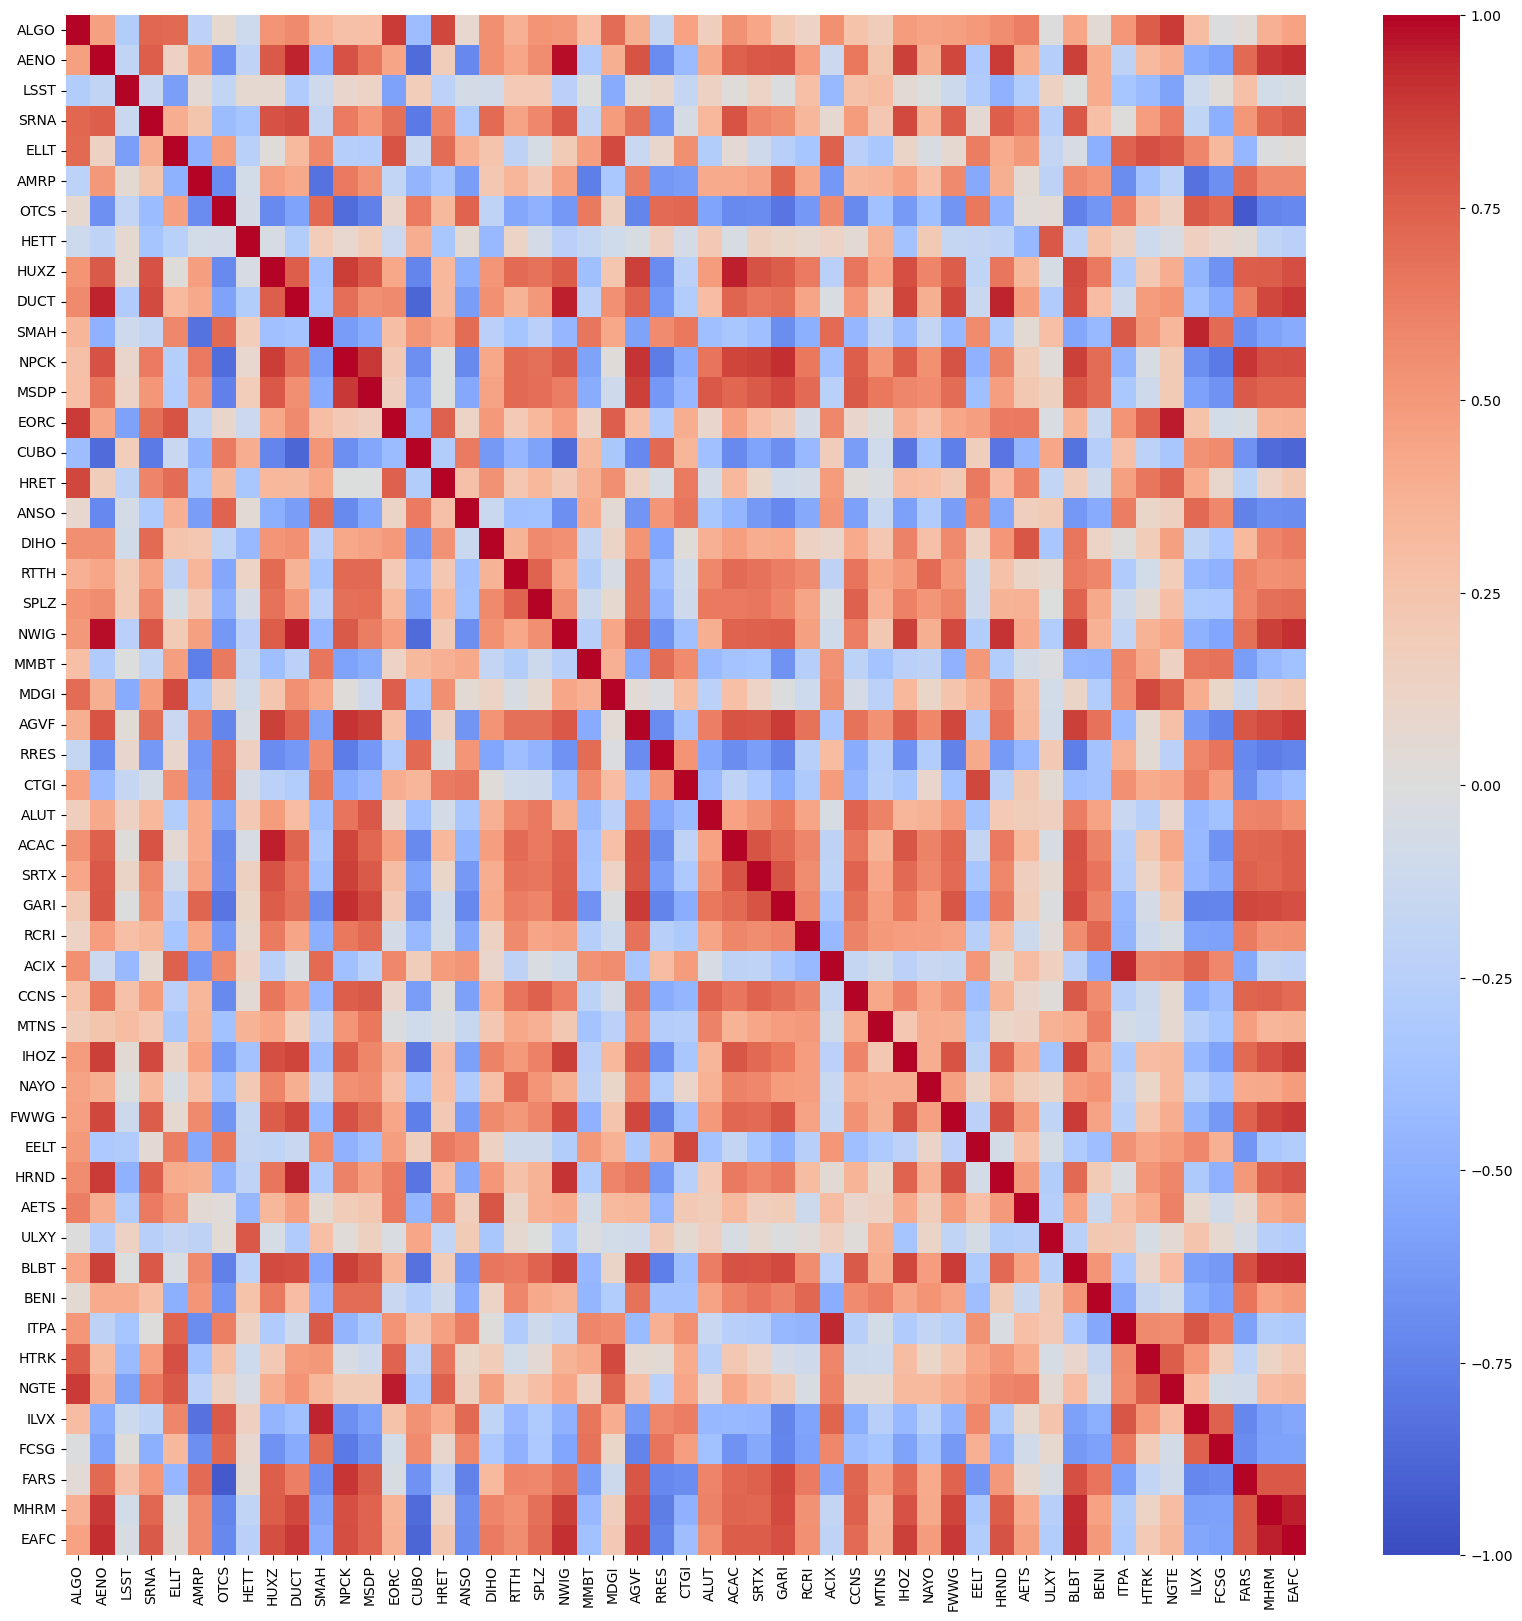

In [28]:
matrix1 = np.log(prices).corr('spearman')
plt.figure(figsize=(20,20))
sns.heatmap(data=matrix1, cmap='coolwarm', vmin=-1, vmax=1)


<Axes: >

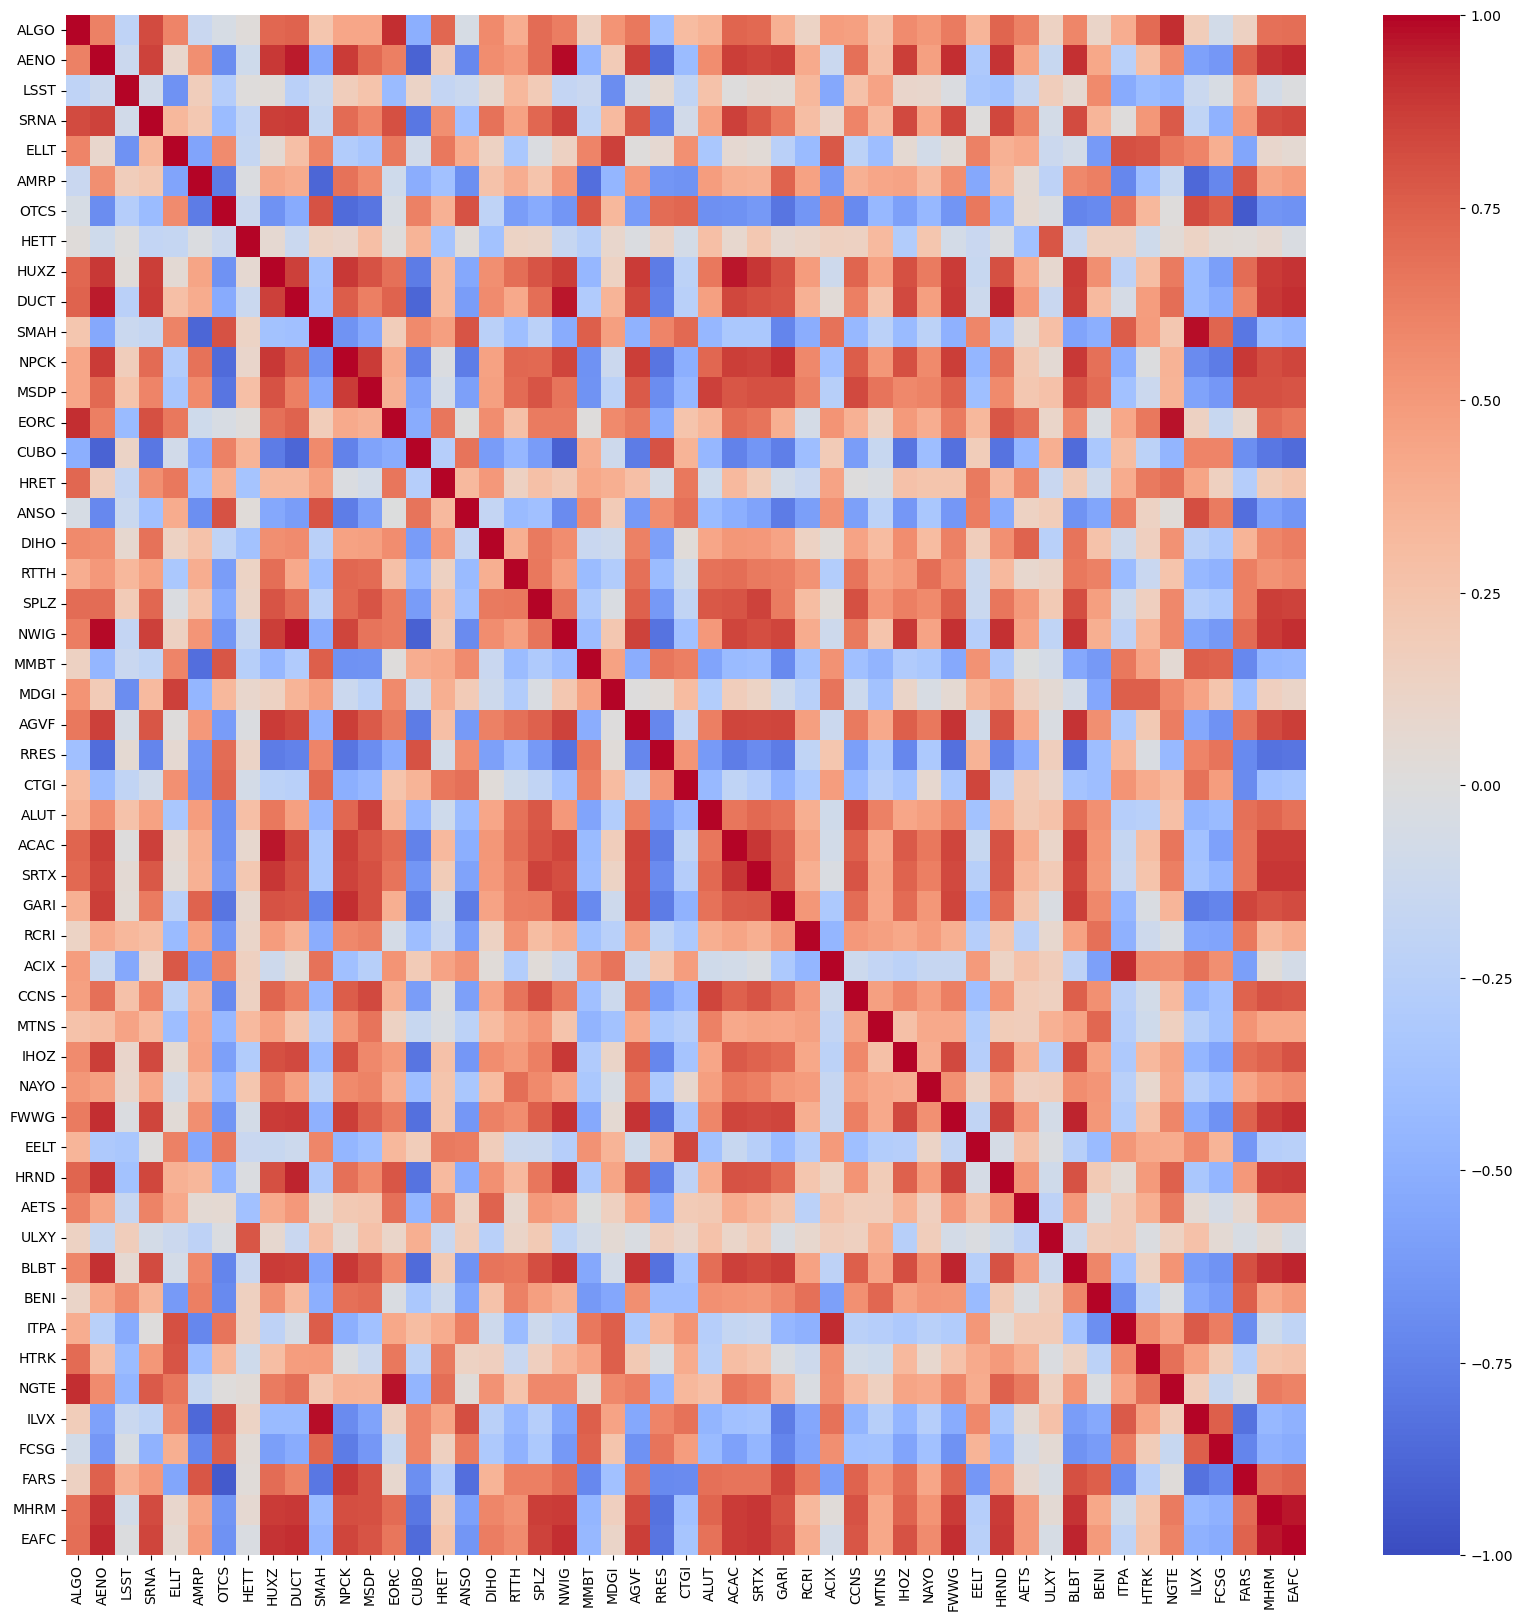

In [30]:
matrix2 = np.log(prices).corr('pearson')
plt.figure(figsize=(20,20))
sns.heatmap(data=matrix2, cmap='coolwarm', vmin=-1, vmax=1)

<Axes: >

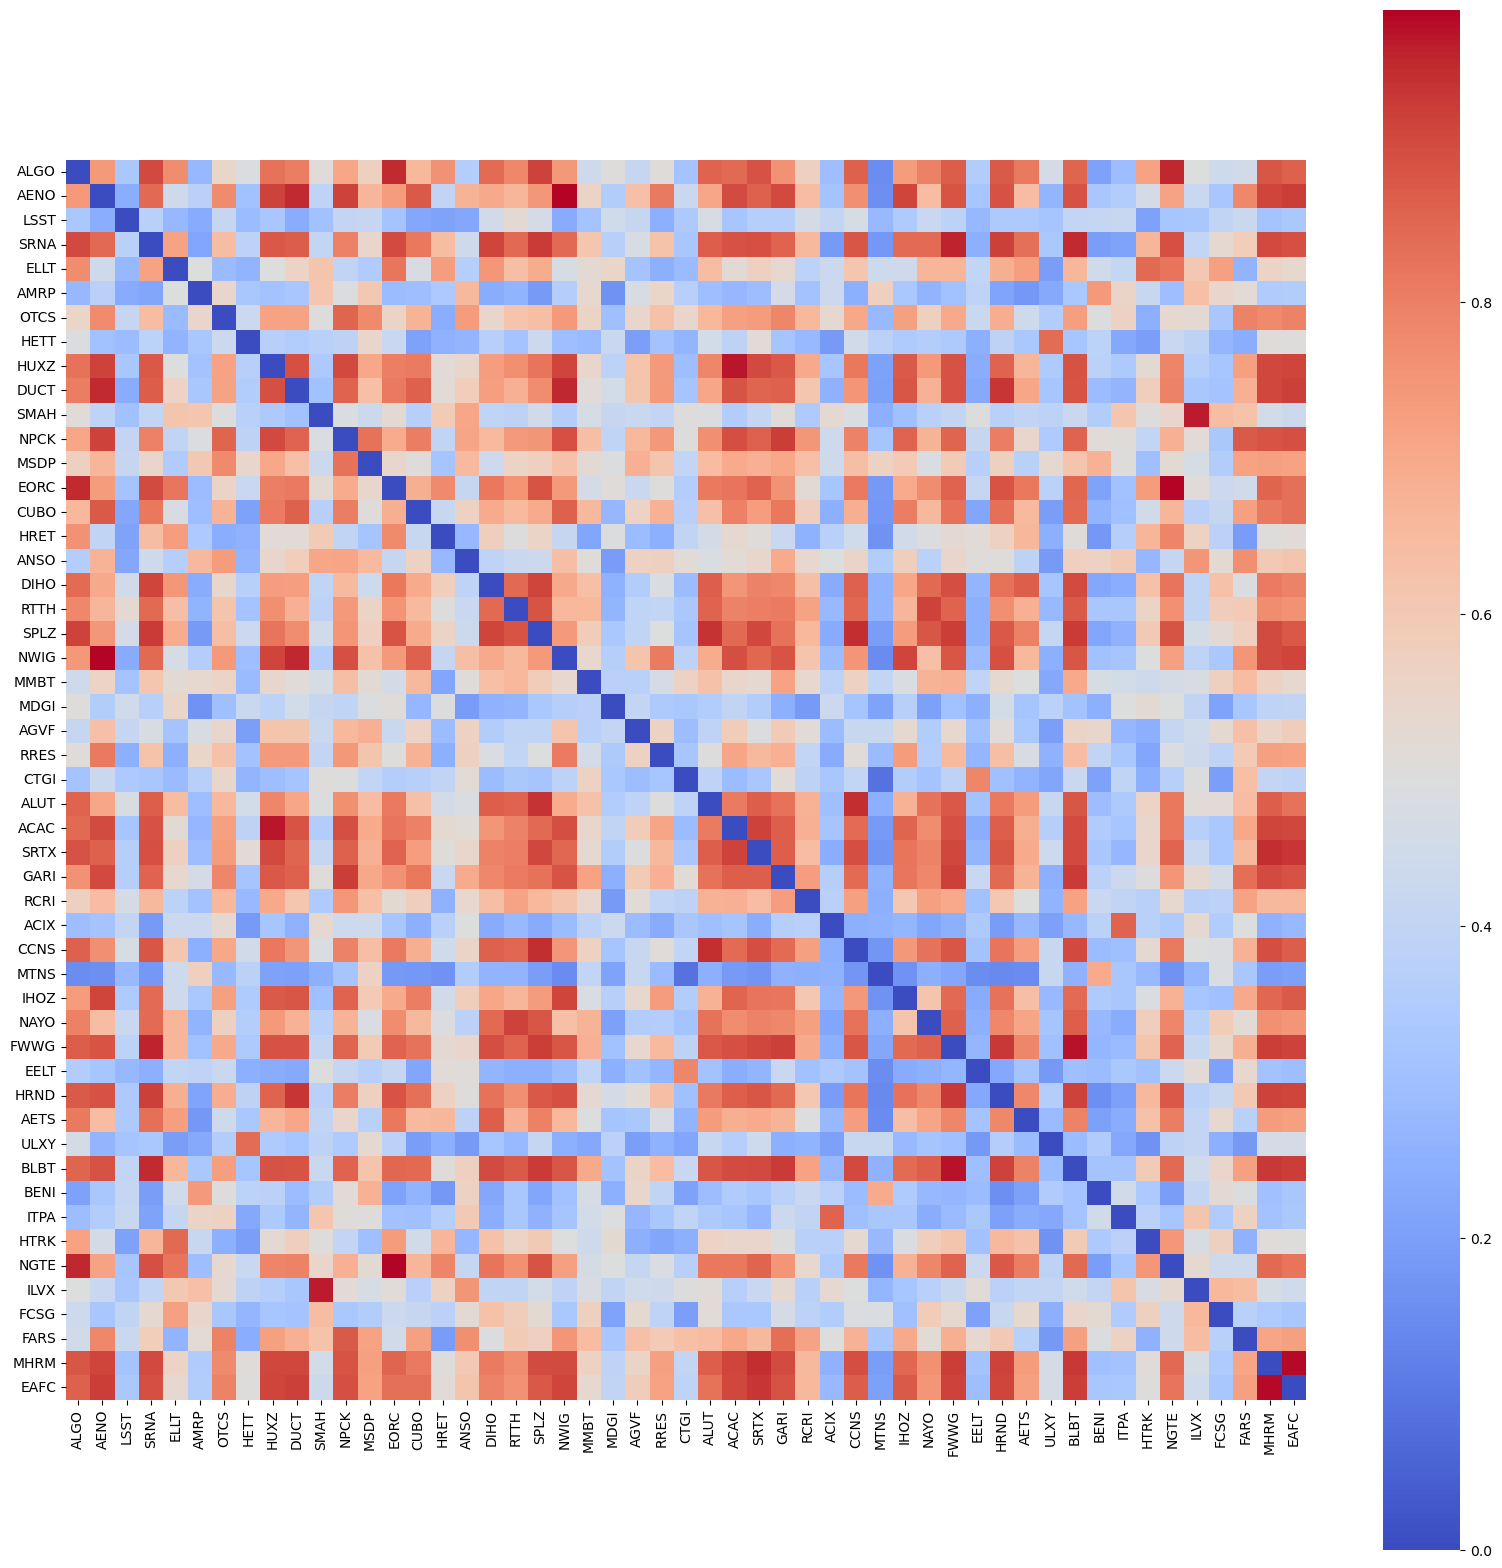

In [9]:
dcorr_df = pd.read_csv('dcorr_df.csv')
from scipy.spatial.distance import squareform
import pandas as pd

condensed = dcorr_df.sort_values(['instrument_1', 'instrument_2'])['distance_corr'].values
dcorr_matrix = squareform(condensed)
n = 51
dcorr_df_square = pd.DataFrame(dcorr_matrix,
                                 index=[f'{prices.columns.values[k]}' for k in range(n)],
                                 columns=[f'{prices.columns.values[k]}' for k in range(n)])

np.fill_diagonal(dcorr_matrix, 1.0)
plt.figure(figsize=(20,20))
sns.heatmap(dcorr_df_square, cmap='coolwarm', square=True)

<Axes: >

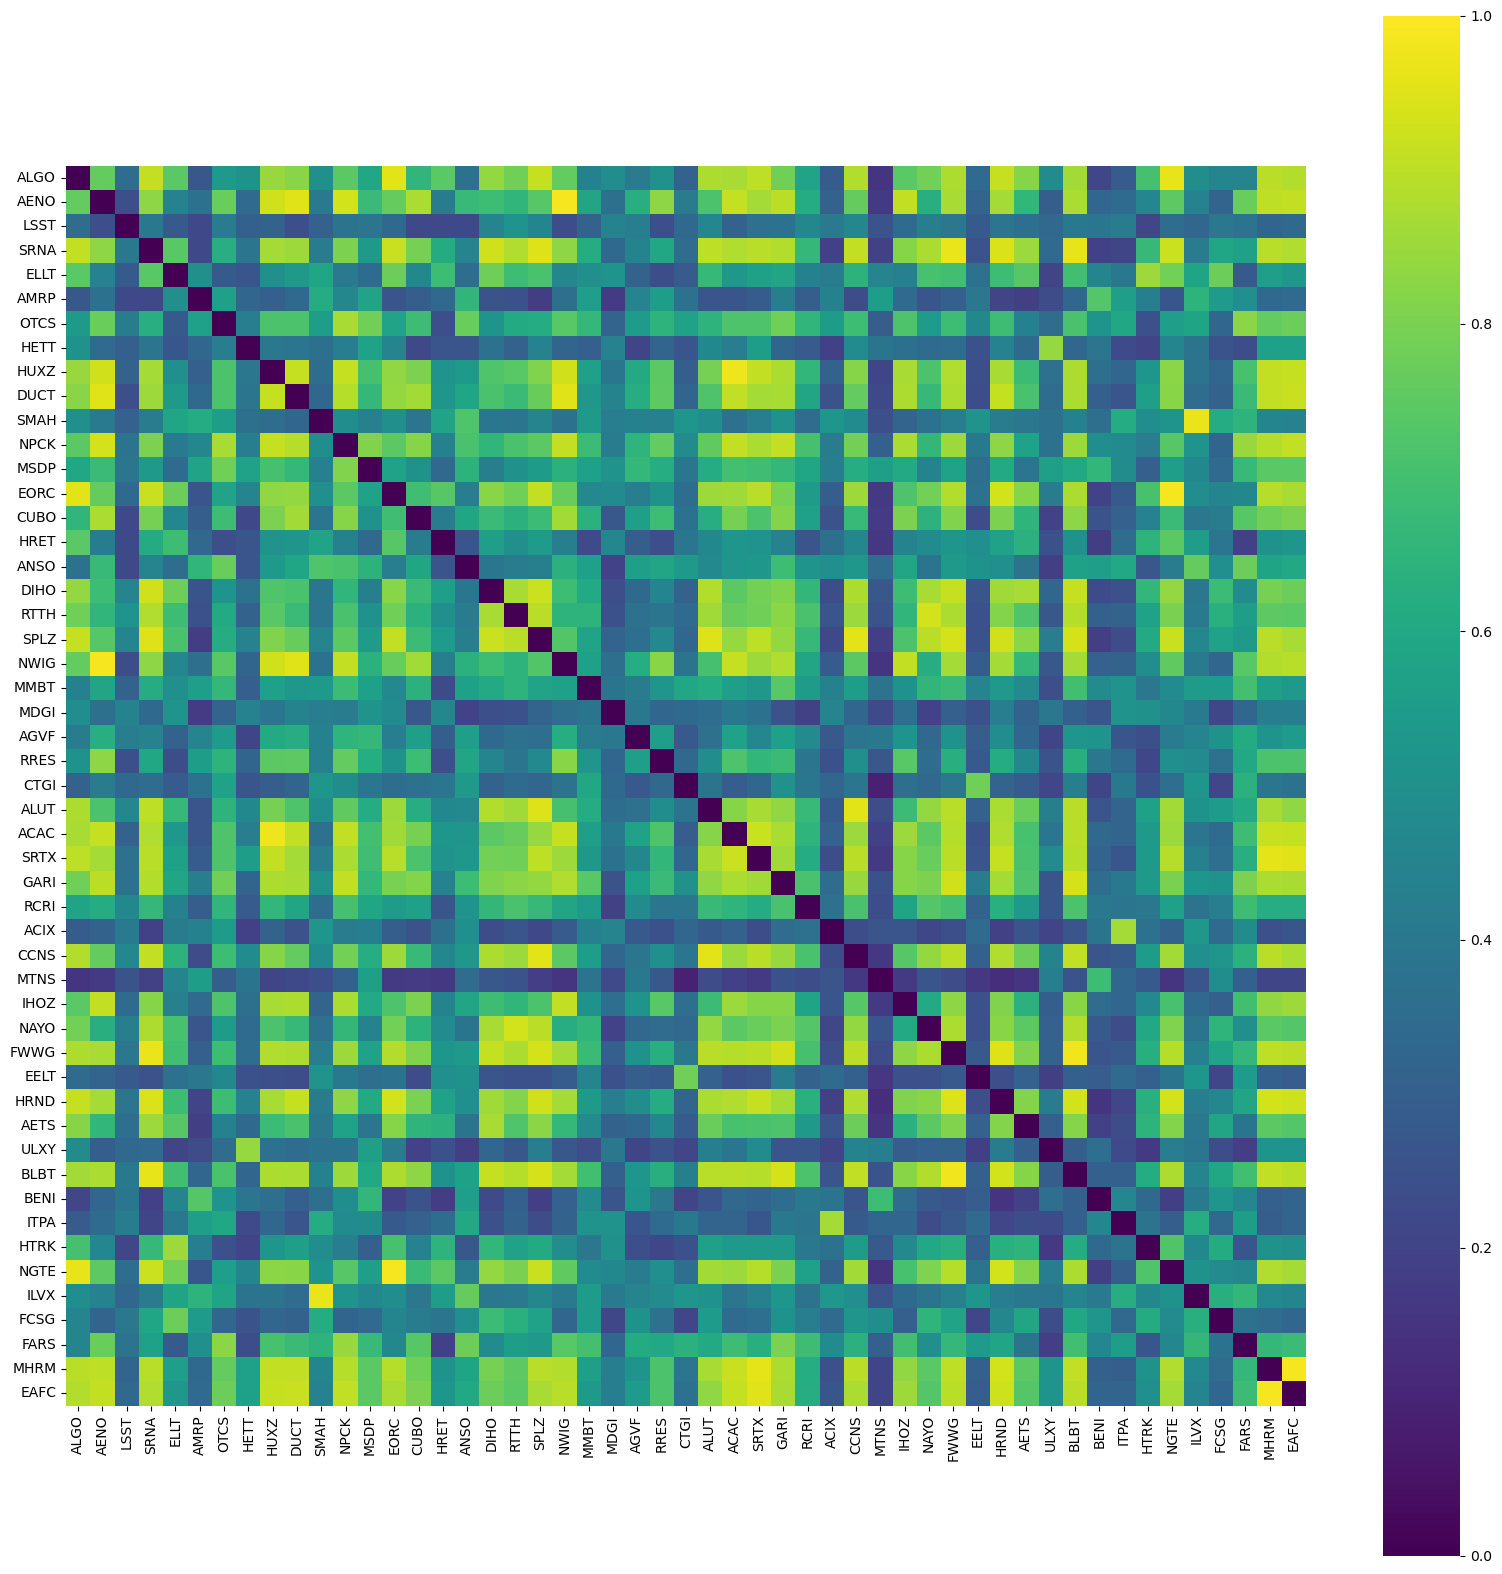

In [29]:
dcorr_returns = pd.read_csv('log_price_dcorr_df.csv')
condensed = dcorr_returns.sort_values(['instrument_1', 'instrument_2'])['distance_corr'].values
dcorr_matrix = squareform(condensed)
n = 51
dcorr_df_square = pd.DataFrame(dcorr_matrix,
                                 index=[f'{prices.columns.values[k]}' for k in range(n)],
                                 columns=[f'{prices.columns.values[k]}' for k in range(n)])

np.fill_diagonal(dcorr_matrix, 1.0)
plt.figure(figsize=(20,20))
sns.heatmap(dcorr_df_square, cmap='viridis', square=True, vmin=0.0, vmax=1.0)


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

prices = np.log(pd.read_csv("prices.csv").iloc[:500])

for a in prices.columns:
    # Use returns rather than prices
    x = prices[a].to_numpy()
    y = prices['MHRM'].to_numpy()

    # Remove the mean
    x = x - np.mean(x)
    y = y - np.mean(y)

    # Compute normalized cross-correlation
    corr = signal.correlate(x, y, mode="full")
    lags = signal.correlation_lags(len(x), len(y), mode="full")
    corr = corr / (len(x) * np.std(x) * np.std(y))

    # Find the strongest correlation (positive or negative)
    idx = np.argmax(np.abs(corr))

    print(f"{a} vs MHRM")
    print(f"Best lag: {lags[idx]}")
    print(f"Correlation: {corr[idx]:.4f}")

    if lags[idx] > 0:
        print(f"→ MMBT leads {a} by {lags[idx]} days")
    elif lags[idx] < 0:
        print(f"→ {a} leads MMBT by {-lags[idx]} days")
    else:
        print("→ No lead-lag relationship (peak at lag 0)")

    # plt.figure(figsize=(8, 4))
    # plt.plot(lags, corr)
    # plt.axvline(0, color="black", linestyle="--")
    # plt.axhline(0, color="grey", linestyle=":")
    # plt.title(f"Cross-correlation: {a} vs MMBT")
    # plt.xlabel("Lag (days)")
    # plt.ylabel("Normalized cross-correlation")
    # plt.grid(True)
    # plt.show()



ALGO vs MHRM
Best lag: 0
Correlation: 0.6682
→ No lead-lag relationship (peak at lag 0)
AENO vs MHRM
Best lag: 0
Correlation: 0.9100
→ No lead-lag relationship (peak at lag 0)
LSST vs MHRM
Best lag: -151
Correlation: 0.5518
→ LSST leads MMBT by 151 days
SRNA vs MHRM
Best lag: 0
Correlation: 0.8163
→ No lead-lag relationship (peak at lag 0)
ELLT vs MHRM
Best lag: -159
Correlation: -0.6321
→ ELLT leads MMBT by 159 days
AMRP vs MHRM
Best lag: -77
Correlation: 0.7022
→ AMRP leads MMBT by 77 days
OTCS vs MHRM
Best lag: 0
Correlation: -0.6740
→ No lead-lag relationship (peak at lag 0)
HETT vs MHRM
Best lag: -365
Correlation: -0.3982
→ HETT leads MMBT by 365 days
HUXZ vs MHRM
Best lag: 0
Correlation: 0.8735
→ No lead-lag relationship (peak at lag 0)
DUCT vs MHRM
Best lag: 0
Correlation: 0.8819
→ No lead-lag relationship (peak at lag 0)
SMAH vs MHRM
Best lag: -94
Correlation: -0.7543
→ SMAH leads MMBT by 94 days
NPCK vs MHRM
Best lag: 0
Correlation: 0.8099
→ No lead-lag relationship (peak at l

Price Level PCA

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca.fit(np.log(prices))
print(f"Entire price series variance ratio: {pca.explained_variance_ratio_}")

Entire price series variance ratio: [0.61655557 0.19404015 0.04583514 0.02869813 0.02379652 0.02057369
 0.01129118 0.00945278]


In [35]:
loadings = pca.components_.T
loading_df = pd.DataFrame(data=loadings, columns=[f"PC{i}" for i in range(1,9)], index=prices.columns)
print(loading_df)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
ALGO  0.027103  0.062475 -0.047536 -0.010697  0.034280 -0.008943  0.017214   
AENO  0.188805  0.046312  0.123883 -0.047081  0.055661  0.068151 -0.079137   
LSST -0.000161 -0.087991 -0.174911  0.048323  0.160606  0.143452 -0.143019   
SRNA  0.118093  0.113498 -0.027391  0.033655  0.139154  0.022542 -0.217416   
ELLT -0.010773  0.217508  0.101590 -0.057057 -0.013129 -0.023433  0.011936   
AMRP  0.139681 -0.235308  0.210227  0.253658 -0.080960 -0.110687  0.135581   
OTCS -0.241955  0.294711  0.037570  0.183417  0.084222 -0.041728  0.181732   
HETT  0.001255 -0.015960 -0.117404 -0.145664 -0.206503 -0.146729  0.050379   
HUXZ  0.151229  0.047131 -0.107702 -0.038018  0.098022 -0.094183 -0.123384   
DUCT  0.257159  0.170643  0.193511 -0.114238  0.127213  0.089272  0.090974   
SMAH -0.106676  0.204923 -0.201445 -0.108038 -0.006873 -0.051537 -0.233657   
NPCK  0.369252 -0.143135 -0.153623 -0.095396  0.172764 -0.185654

In [36]:
for i in range(1,9):
    pc = loading_df[f'PC{i}'].sort_values(ascending=False)
    print(f'PC{i}')
    print(pc.head())
    print()

PC1
NPCK    0.369252
HRND    0.346652
MHRM    0.259230
DUCT    0.257159
GARI    0.233050
Name: PC1, dtype: float64

PC2
EORC    0.331369
HRND    0.303947
OTCS    0.294711
NGTE    0.282548
MMBT    0.227644
Name: PC2, dtype: float64

PC3
HRND    0.340231
AMRP    0.210227
DUCT    0.193511
NWIG    0.153934
AENO    0.123883
Name: PC3, dtype: float64

PC4
AETS    0.540203
DIHO    0.364111
AMRP    0.253658
ANSO    0.193269
OTCS    0.183417
Name: PC4, dtype: float64

PC5
MMBT    0.377955
RCRI    0.279654
HRET    0.273180
RTTH    0.189123
CTGI    0.186557
Name: PC5, dtype: float64

PC6
MMBT    0.367222
CCNS    0.310440
FCSG    0.302914
MHRM    0.250440
EAFC    0.200088
Name: PC6, dtype: float64

PC7
RRES    0.301922
RCRI    0.249683
NAYO    0.248957
GARI    0.243003
EELT    0.213435
Name: PC7, dtype: float64

PC8
HRND    0.358330
RCRI    0.283214
NAYO    0.242847
MTNS    0.234504
ILVX    0.196432
Name: PC8, dtype: float64



In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

normalised_prices = scaler.fit_transform(prices)
scores = pca.fit_transform(normalised_prices)
